In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs('/content/drive/MyDrive/XAIProject/dataset', exist_ok=True)

In [ ]:
!pip -q install gdown ecdsa scikit-learn



import os
import sys
import json
import pickle
import zipfile
import shutil
from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import torch

# Configuration
CODE_ZIP_URL = "https://drive.google.com/uc?id=1ccGKjbUKKv0hO5ceLjKQV7IU8TU9HcFq"

DATA_URL = " https://drive.google.com/file/d/1v1yBEMwe4j49eb9UiYqeD57zjw3HEthT/view?usp=sharing"

ROOT = Path("/content/drive/MyDrive/XAIProject")
ZIP_PATH = ROOT / "ExplainAI_Project.zip"
DATA_DIR = ROOT / "dataset"
DATA_PATH = DATA_DIR / "cicids2017.csv"
UTILS_DIR = ROOT / "utils"
SAVE_DIR = ROOT / "saved_models"

ROOT.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def download_file(url, output_path):
    output_path = str(output_path)
    gdown.download(url, output_path, quiet=False, fuzzy=True)

print("Downloading project zip...")
download_file(CODE_ZIP_URL, ZIP_PATH)

print("\nExtracting project zip...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(ROOT)

print("Downloading dataset...")
download_file(DATA_URL, DATA_PATH)


init_path = UTILS_DIR / "__init__.py"
init_path.parent.mkdir(parents=True, exist_ok=True)
init_path.write_text("", encoding="utf-8")

print("\nProject root:", ROOT)
print("Utils directory exists:", UTILS_DIR.exists())
print("Dataset exists:", DATA_PATH.exists())
print("GPU available:", torch.cuda.is_available())

print("\nUtility files:")
for item in sorted(UTILS_DIR.glob("*.py")):
    print(" -", item.name)

dataset_size_mb = DATA_PATH.stat().st_size / (1024 * 1024)
print(f"\nDataset size: {dataset_size_mb:.2f} MB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 kB 3.8 MB/s eta 0:00:00


Downloading...
From: https://drive.google.com/uc?id=1ccGKjbUKKv0hO5ceLjKQV7IU8TU9HcFq
To: /content/drive/MyDrive/XAIProject/ExplainAI_Project.zip
100%|██████████| 6.51k/6.51k [00:00<00:00, 17.9MB/s]



Extracting project zip...


Downloading...
From: https://drive.google.com/uc?id=1v1yBEMwe4j49eb9UiYqeD57zjw3HEthT
To: /content/drive/MyDrive/XAIProject/dataset/cicids2017.csv
100%|██████████| 64.5M/64.5M [00:00<00:00, 103MB/s] 



Project root: /content/drive/MyDrive/XAIProject
Utils directory exists: True
Dataset exists: True
GPU available: True

Utility files:
 - __init__.py
 - activation_capture.py
 - certificate.py
 - cnn_lstm.py
 - explanation_drift.py
 - hash_chain.py
 - intrinsic_explainer.py
 - quantization.py
 - transformer_model.py

Dataset size: 61.53 MB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

MAX_FULL_LOAD_MB = 250
RANDOM_STATE = 42
TARGET_PER_CLASS = {
    "benign": 100000,
    "dos hulk": 50000,
    "dos goldeneye": 20000,
    "dos slowloris": 20000,
    "dos slowhttptest": 20000,
    "heartbleed": 10000,
}

WORKING_DATA_PATH = DATA_PATH

def build_balanced_subset_from_large_csv(input_csv, output_csv, target_per_class):
    collected = {k: [] for k in target_per_class}
    counts = {k: 0 for k in target_per_class}
    label_col = None

    for chunk_idx, chunk in enumerate(pd.read_csv(input_csv, chunksize=100000, low_memory=False, on_bad_lines="skip")):
        if label_col is None:
            label_col = "label" if "label" in chunk.columns else ("Label" if "Label" in chunk.columns else None)
            if label_col is None:
                raise KeyError(f"No label column found. Columns include: {list(chunk.columns[:20])}")

        labels = chunk[label_col].astype(str).str.strip().str.lower()
        valid_mask = labels != "nan"
        chunk = chunk.loc[valid_mask].copy()
        labels = labels.loc[valid_mask]

        for cls, target in target_per_class.items():
            remaining = target - counts[cls]
            if remaining <= 0:
                continue

            take = chunk.loc[labels == cls].head(remaining)
            if len(take) > 0:
                collected[cls].append(take)
                counts[cls] += len(take)

        print(f"Chunk {chunk_idx + 1}: {counts}")

    parts = []
    for cls in target_per_class:
        if collected[cls]:
            parts.extend(collected[cls])

    if not parts:
        raise ValueError("No rows were collected for the balanced subset.")

    subset = pd.concat(parts, ignore_index=True)
    subset = subset.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    subset.to_csv(output_csv, index=False)
    return output_csv

dataset_size_mb = DATA_PATH.stat().st_size / (1024 * 1024)
if dataset_size_mb > MAX_FULL_LOAD_MB:
    print("Large dataset detected. Building a balanced Colab-friendly subset...")
    WORKING_DATA_PATH = DATA_DIR / "balanced_subset.csv"
    build_balanced_subset_from_large_csv(DATA_PATH, WORKING_DATA_PATH, TARGET_PER_CLASS)
    print("Balanced subset saved to:", WORKING_DATA_PATH)
else:
    print("Using the provided dataset directly.")

df = pd.read_csv(WORKING_DATA_PATH, low_memory=False, on_bad_lines="skip")
label_col = "label" if "label" in df.columns else ("Label" if "Label" in df.columns else None)
if label_col is None:
    raise KeyError(f"No label column found. Columns include: {list(df.columns[:20])}")

labels = df[label_col].astype(str).str.strip().str.lower()
valid_mask = labels != "nan"
df = df.loc[valid_mask].copy()
labels = labels.loc[valid_mask]

X_df = df.drop(columns=[c for c in [label_col, "source_dataset", "Source_Dataset"] if c in df.columns], errors="ignore")
X_df = X_df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], 0).fillna(0).astype(np.float32)

X = X_df.to_numpy(dtype=np.float32)
y_text = labels.to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("Working dataset:", WORKING_DATA_PATH.name)
print("Dataset shape:", X.shape)
print("Classes:", list(label_encoder.classes_))
print("\nLabel distribution:")
print(pd.Series(y_text).value_counts())

# First carve out a held-out test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Then split the remainder into train / val (80/20 of what remains)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_trainval
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train).long())
val_ds = TensorDataset(torch.from_numpy(X_val_scaled), torch.from_numpy(y_val).long())

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


test_ds     = TensorDataset(
    torch.from_numpy(scaler.transform(X_test).astype(np.float32)),
    torch.from_numpy(y_test).long()
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train rows :", len(train_ds))
print("Val rows   :", len(val_ds))
print("Test rows  :", len(test_ds))

Using the provided dataset directly.
Working dataset: cicids2017.csv
Dataset shape: (35011, 437)
Classes: ['benign', 'dos goldeneye', 'dos hulk', 'dos slowhttptest', 'dos slowloris', 'heartbleed']

Label distribution:
benign              10000
dos hulk            10000
dos slowhttptest     5000
dos goldeneye        5000
dos slowloris        5000
heartbleed             11
Name: count, dtype: int64
Train rows : 23807
Val rows   : 5952
Test rows  : 5252


In [ ]:
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report

sys.path.insert(0, str(UTILS_DIR))
from transformer_model import TabularTransformer

DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS        = 50
LEARNING_RATE = 1e-4

transformer_model = TabularTransformer(
    input_dim=X.shape[1],
    hidden_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=len(label_encoder.classes_),
    dropout=0.1
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=LEARNING_RATE)

best_val_acc = 0.0
best_state   = None
history      = []

print("Training TabularTransformer on device:", DEVICE)

for epoch in range(EPOCHS):
    transformer_model.train()
    train_loss = 0.0
    train_preds, train_true = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = transformer_model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
        train_true.extend(yb.detach().cpu().numpy())

    train_loss /= len(train_ds)
    train_acc   = accuracy_score(train_true, train_preds)

    transformer_model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = transformer_model(xb)
            loss    = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    val_loss /= len(val_ds)
    val_acc   = accuracy_score(val_true, val_preds)

    test_preds_ep, test_true_ep = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            test_preds_ep.extend(torch.argmax(transformer_model(xb), dim=1).cpu().numpy())
            test_true_ep.extend(yb.numpy())
    test_acc = accuracy_score(test_true_ep, test_preds_ep)

    history.append({
        "epoch":      epoch + 1,
        "train_loss": train_loss,
        "train_acc":  train_acc,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
        "test_acc":   test_acc,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"test_acc={test_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu() for k, v in transformer_model.state_dict().items()}

if best_state is None:
    raise RuntimeError("Training did not produce a best model state.")

TRANSFORMER_MODEL_PATH = SAVE_DIR / "transformer_balanced_6class.pt"
SCALER_PATH            = SAVE_DIR / "balanced_scaler.pkl"
LABEL_ENCODER_PATH     = SAVE_DIR / "balanced_label_encoder.pkl"
HISTORY_PATH           = SAVE_DIR / "transformer_training_history.csv"
TRAIN_FEATURES_PATH    = SAVE_DIR / "train_feature_names.json"

torch.save(best_state, TRANSFORMER_MODEL_PATH)
with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)
with open(LABEL_ENCODER_PATH, "wb") as f:
    pickle.dump(label_encoder, f)
pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

# Save ordered feature names for cross-domain alignment
import json as _json
with open(TRAIN_FEATURES_PATH, "w") as f:
    _json.dump(list(X_df.columns), f)

transformer_model.load_state_dict(best_state)
transformer_model.eval()
transformer_best_val_acc = best_val_acc

final_preds, final_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        final_preds.extend(torch.argmax(transformer_model(xb), dim=1).cpu().numpy())
        final_true.extend(yb.numpy())

print(f"\nBest validation accuracy (Transformer): {transformer_best_val_acc:.4f}")
print("\nValidation classification report:")
print(classification_report(
    final_true, final_preds,
    target_names=label_encoder.classes_, digits=4, zero_division=0,
))

print("HELD-OUT TEST SET EVALUATION")
test_preds_final, test_true_final = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        test_preds_final.extend(torch.argmax(transformer_model(xb), dim=1).cpu().numpy())
        test_true_final.extend(yb.numpy())

transformer_test_acc = accuracy_score(test_true_final, test_preds_final)
print(f"\nTest accuracy : {transformer_test_acc:.4f}")
print(f"Val accuracy  : {transformer_best_val_acc:.4f}")
print(f"Delta         : {transformer_test_acc - transformer_best_val_acc:+.4f}")
print("\nTest classification report:")
print(classification_report(
    test_true_final, test_preds_final,
    target_names=label_encoder.classes_, digits=4, zero_division=0,
))
print("Saved Transformer model     ->", TRANSFORMER_MODEL_PATH)
print("Saved feature names         ->", TRAIN_FEATURES_PATH)


Training TabularTransformer on device: cuda
Epoch 1/50 | train_loss=0.9556 train_acc=0.6646 | val_loss=0.2442 val_acc=0.9276 | test_acc=0.9294
Epoch 2/50 | train_loss=0.1814 train_acc=0.9464 | val_loss=0.0928 val_acc=0.9724 | test_acc=0.9682
Epoch 3/50 | train_loss=0.1032 train_acc=0.9698 | val_loss=0.0680 val_acc=0.9807 | test_acc=0.9794
Epoch 4/50 | train_loss=0.0809 train_acc=0.9749 | val_loss=0.0614 val_acc=0.9773 | test_acc=0.9770
Epoch 5/50 | train_loss=0.0674 train_acc=0.9787 | val_loss=0.0519 val_acc=0.9854 | test_acc=0.9846
Epoch 6/50 | train_loss=0.0577 train_acc=0.9823 | val_loss=0.0554 val_acc=0.9829 | test_acc=0.9815
Epoch 7/50 | train_loss=0.0522 train_acc=0.9845 | val_loss=0.0532 val_acc=0.9837 | test_acc=0.9840
Epoch 8/50 | train_loss=0.0484 train_acc=0.9848 | val_loss=0.0439 val_acc=0.9877 | test_acc=0.9886
Epoch 9/50 | train_loss=0.0460 train_acc=0.9858 | val_loss=0.0425 val_acc=0.9867 | test_acc=0.9884
Epoch 10/50 | train_loss=0.0443 train_acc=0.9863 | val_loss=0.040

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report


class CNNLSTMHybrid(nn.Module):
    def __init__(
        self,
        input_dim,
        cnn_channels=128,
        lstm_hidden=256,
        lstm_layers=2,
        num_classes=35,
        dropout=0.3,
    ):
        super(CNNLSTMHybrid, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        # LSTM over CNN output tokens
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.classifier(last_out)


NUM_CLASSES = len(label_encoder.classes_)

cnnlstm_model = CNNLSTMHybrid(
    input_dim=X.shape[1],
    cnn_channels=128,
    lstm_hidden=256,
    lstm_layers=2,
    num_classes=NUM_CLASSES,
    dropout=0.3,
).to(DEVICE)

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.AdamW(cnnlstm_model.parameters(), lr=LEARNING_RATE)

best_val_acc_cnn = 0.0
best_state_cnn   = None
history_cnn      = []

print(f"Model : CNNLSTMHybrid | input_dim={X.shape[1]} | classes={NUM_CLASSES}")
print(f"Device: {DEVICE}\n")

for epoch in range(EPOCHS):
    # train
    cnnlstm_model.train()
    train_loss = 0.0
    train_preds, train_true = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_cnn.zero_grad()
        logits = cnnlstm_model(xb)
        loss   = criterion_cnn(logits, yb)
        loss.backward()
        optimizer_cnn.step()

        train_loss += loss.item() * xb.size(0)
        train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
        train_true.extend(yb.detach().cpu().numpy())

    train_loss /= len(train_ds)
    train_acc   = accuracy_score(train_true, train_preds)

    # validate
    cnnlstm_model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits   = cnnlstm_model(xb)
            val_loss += criterion_cnn(logits, yb).item() * xb.size(0)
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    val_loss /= len(val_ds)
    val_acc   = accuracy_score(val_true, val_preds)

    # held-out test per epoch
    test_preds_ep, test_true_ep = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            test_preds_ep.extend(torch.argmax(cnnlstm_model(xb), dim=1).cpu().numpy())
            test_true_ep.extend(yb.numpy())
    test_acc = accuracy_score(test_true_ep, test_preds_ep)

    history_cnn.append({
        "epoch":      epoch + 1,
        "train_loss": train_loss,
        "train_acc":  train_acc,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
        "test_acc":   test_acc,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f} | "
        f"test_acc={test_acc:.4f}"
    )

    if val_acc > best_val_acc_cnn:
        best_val_acc_cnn = val_acc
        best_state_cnn   = {k: v.cpu() for k, v in cnnlstm_model.state_dict().items()}

if best_state_cnn is None:
    raise RuntimeError("CNN-LSTM training produced no best state.")

CNNLSTM_MODEL_PATH = SAVE_DIR / "cnnlstm_balanced_6class.pt"
HISTORY_CNN_PATH   = SAVE_DIR / "cnnlstm_training_history.csv"

torch.save(best_state_cnn, CNNLSTM_MODEL_PATH)
pd.DataFrame(history_cnn).to_csv(HISTORY_CNN_PATH, index=False)

cnnlstm_model.load_state_dict(best_state_cnn)
cnnlstm_model.eval()
cnnlstm_best_val_acc = best_val_acc_cnn

final_preds, final_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        final_preds.extend(torch.argmax(cnnlstm_model(xb), dim=1).cpu().numpy())
        final_true.extend(yb.numpy())

print(f"\nBest validation accuracy (CNN-LSTM): {cnnlstm_best_val_acc:.4f}")
print("\nValidation classification report:")
print(classification_report(
    final_true, final_preds,
    target_names=label_encoder.classes_, digits=4, zero_division=0,
))

print("HELD-OUT TEST SET EVALUATION")
test_preds_final, test_true_final = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        test_preds_final.extend(torch.argmax(cnnlstm_model(xb), dim=1).cpu().numpy())
        test_true_final.extend(yb.numpy())

cnnlstm_test_acc = accuracy_score(test_true_final, test_preds_final)
print(f"\nTest accuracy : {cnnlstm_test_acc:.4f}")
print(f"Val accuracy  : {cnnlstm_best_val_acc:.4f}")
print(f"Delta         : {cnnlstm_test_acc - cnnlstm_best_val_acc:+.4f}")
print("\nTest classification report:")
print(classification_report(
    test_true_final, test_preds_final,
    target_names=label_encoder.classes_, digits=4, zero_division=0,
))
print("Saved CNN-LSTM model        ->", CNNLSTM_MODEL_PATH)
print("Saved CNN-LSTM history      ->", HISTORY_CNN_PATH)


Model : CNNLSTMHybrid | input_dim=437 | classes=6
Device: cuda

Epoch 1/50 | train_loss=1.6607  train_acc=0.2501 | val_loss=1.5469  val_acc=0.2853 | test_acc=0.2698
Epoch 2/50 | train_loss=1.4423  train_acc=0.3378 | val_loss=1.1406  val_acc=0.5020 | test_acc=0.5063
Epoch 3/50 | train_loss=1.0858  train_acc=0.4840 | val_loss=0.9323  val_acc=0.6237 | test_acc=0.6318
Epoch 4/50 | train_loss=0.9179  train_acc=0.5767 | val_loss=0.9340  val_acc=0.6069 | test_acc=0.5992
Epoch 5/50 | train_loss=0.7493  train_acc=0.6898 | val_loss=0.6005  val_acc=0.8091 | test_acc=0.8123
Epoch 6/50 | train_loss=0.6217  train_acc=0.7621 | val_loss=0.4120  val_acc=0.8594 | test_acc=0.8629
Epoch 7/50 | train_loss=0.5475  train_acc=0.8013 | val_loss=0.4275  val_acc=0.8622 | test_acc=0.8656
Epoch 8/50 | train_loss=0.4274  train_acc=0.8554 | val_loss=0.3116  val_acc=0.8894 | test_acc=0.8930
Epoch 9/50 | train_loss=0.3338  train_acc=0.8819 | val_loss=0.2798  val_acc=0.8950 | test_acc=0.8951
Epoch 10/50 | train_loss=0.

Benign class ids in encoder : frozenset({0})
All training classes        : ['benign', 'dos goldeneye', 'dos hulk', 'dos slowhttptest', 'dos slowloris', 'heartbleed']

Loading external datasets...

  CIC-DDoS2019: 50000 rows  (benign=11393  attack=38607)
  Unique labels : ['Benign', 'DrDoS_DNS', 'DrDoS_LDAP', 'DrDoS_MSSQL', 'DrDoS_NTP', 'DrDoS_NetBIOS', 'DrDoS_SNMP', 'DrDoS_UDP', 'LDAP', 'MSSQL', 'NetBIOS', 'Portmap', 'Syn', 'TFTP', 'UDP']

  CIC-IoT2023: 50000 rows  (benign=21605  attack=28395)
  Unique labels : ['Attack-Killall-v2', 'Attack-Killer-TCP', 'Attack-TCP-BYPass-V1', 'Attack-TCP-Control', 'Attack-TCP-Flag-ACK', 'Attack-TCP-Flag-ACK-PSH', 'Attack-TCP-Flag-MIX', 'Attack-TCP-Flag-OSYN', 'Attack-TCP-Flag-OSYNP', 'Attack-TCP-Flag-RST-ACK', 'Attack-TCP-Flag-SYN', 'Attack-TCP-Flag-SYN-ACK', 'Attack-TCP-Flag-SYN-TFO', 'Attack-TCP-Flag-SYN-TIME', 'Attack-TCP-IGMP']

  BCC-Packet: 50000 rows  (benign=29510  attack=20490)
  Unique labels : ['Attack', 'Benign', 'Suspicious']

Datasets a

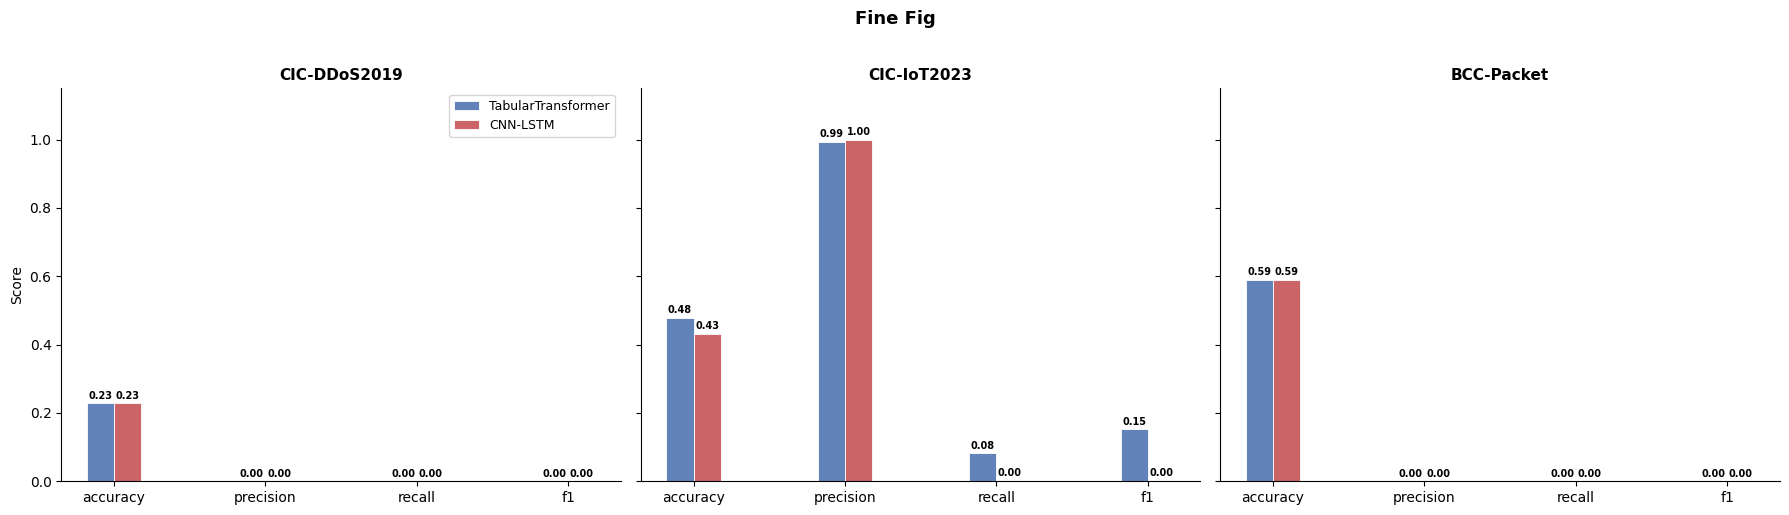

Saved: /content/drive/MyDrive/XAIProject/saved_models/cross_domain_comparison_bars.png


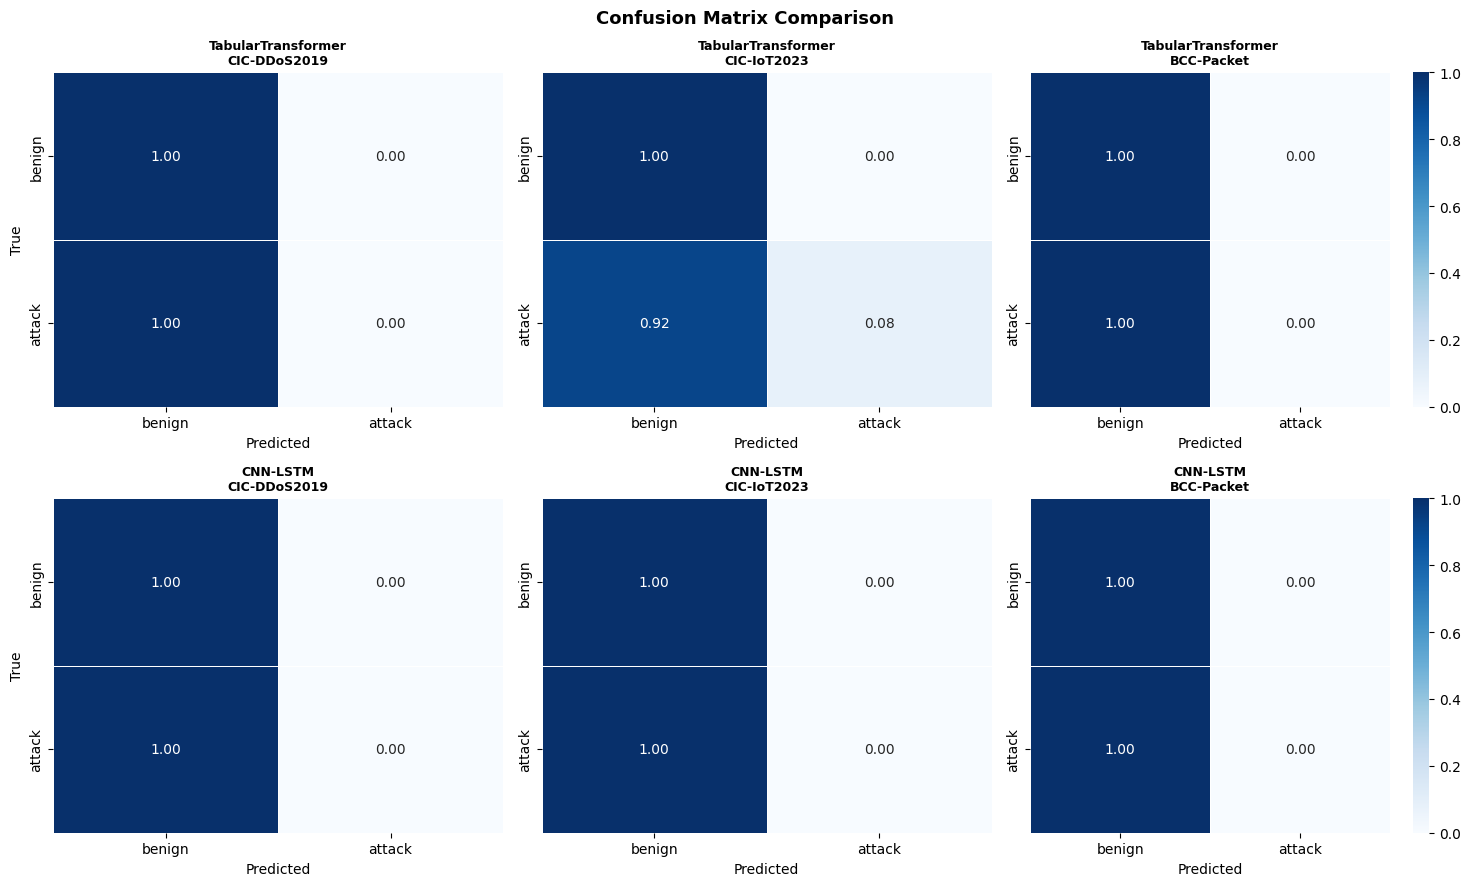

Saved: /content/drive/MyDrive/XAIProject/saved_models/cross_domain_confusion_matrices.png


In [ ]:
from pathlib import Path

import json as _json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dataset paths
CROSS_DOMAIN_DATASETS = {
    "CIC-DDoS2019": Path("/content/drive/MyDrive/XAIProject/dataset/cicddos2019.csv"),
    "CIC-IoT2023":  Path("/content/drive/MyDrive/XAIProject/dataset/ciciot2023.csv"),
    "BCC-Packet":   Path("/content/drive/MyDrive/XAIProject/dataset/bcc_packet.csv"),
}

#Load saved training feature list
TRAIN_FEATURES_PATH = SAVE_DIR / "train_feature_names.json"
with open(TRAIN_FEATURES_PATH) as _f:
    TRAIN_FEATURES = _json.load(_f)

# which model class ids count as 'benign'?
BENIGN_LABELS = {"benign", "normal", "background"}
benign_ids = frozenset(
    i for i, c in enumerate(label_encoder.classes_)
    if c.strip().lower() in BENIGN_LABELS
)
print(f"Benign class ids in encoder : {benign_ids}")
print(f"All training classes        : {list(label_encoder.classes_)}\n")

# Candidates
CANDIDATES = {
    "TabularTransformer": transformer_model,
    "CNN-LSTM":           cnnlstm_model,
}

BATCH_SIZE_EVAL = 512
MAX_ROWS_PER_DS = 50_000   # cap per dataset to avoid Colab OOM; None = use all


# Helpers
def align_features(df_ext, train_features):
    numeric = df_ext.select_dtypes(include=[np.number])
    aligned = pd.DataFrame(0.0, index=df_ext.index,
                           columns=train_features, dtype=np.float32)
    common  = [c for c in train_features if c in numeric.columns]
    aligned[common] = numeric[common].values
    return aligned.replace([np.inf, -np.inf], 0).fillna(0).to_numpy(dtype=np.float32)


def to_binary(raw_label: str) -> int:
    return 0 if raw_label.strip().lower() in BENIGN_LABELS else 1


def load_external_dataset(name, csv_path):
    if not csv_path.exists():
        print(f"  [SKIP] {name}: file not found at {csv_path}")
        return None, None

    df = pd.read_csv(csv_path, low_memory=False, on_bad_lines="skip")
    label_col = next(
        (c for c in df.columns
         if c.strip().lower() in {"label", "attack_type", "class", "traffic_type"}),
        None,
    )
    if label_col is None:
        print(f"  [SKIP] {name}: cannot identify label column. "
              f"Columns: {list(df.columns[:20])}")
        return None, None

    labels_raw = df[label_col].astype(str).str.strip()
    valid      = labels_raw != "nan"
    df         = df.loc[valid].copy()
    labels_raw = labels_raw.loc[valid]

    if MAX_ROWS_PER_DS and len(df) > MAX_ROWS_PER_DS:
        df         = df.sample(MAX_ROWS_PER_DS, random_state=42)
        labels_raw = labels_raw.loc[df.index]

    y_binary  = np.array([to_binary(l) for l in labels_raw], dtype=np.int64)
    X_aligned = align_features(df, TRAIN_FEATURES)
    X_scaled  = scaler.transform(X_aligned).astype(np.float32)

    print(f"  {name}: {len(df)} rows  "
          f"(benign={( y_binary==0).sum()}  attack={(y_binary==1).sum()})")
    print(f"  Unique labels : {sorted(labels_raw.unique())[:15]}")
    return X_scaled, y_binary


def run_inference(mdl, X_scaled, y_binary, batch_size):
    ds     = TensorDataset(torch.from_numpy(X_scaled), torch.from_numpy(y_binary))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_pred, all_true = [], []
    mdl.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb      = xb.to(DEVICE)
            preds_m = torch.argmax(mdl(xb), dim=1).cpu().numpy()
            preds_b = np.array(
                [0 if p in benign_ids else 1 for p in preds_m], dtype=np.int64
            )
            all_pred.extend(preds_b)
            all_true.extend(yb.numpy())
    return np.array(all_true), np.array(all_pred)


#  Main evaluation loop

results = {name: {} for name in CANDIDATES}

print("Loading external datasets...\n")
datasets_loaded = {}
for ds_name, ds_path in CROSS_DOMAIN_DATASETS.items():
    X_s, y_b = load_external_dataset(ds_name, ds_path)
    if X_s is not None:
        datasets_loaded[ds_name] = (X_s, y_b)
    print()

print(f"Datasets available for evaluation: {list(datasets_loaded.keys())}\n")

for mdl_name, mdl in CANDIDATES.items():

    print(f"  MODEL: {mdl_name}")


    for ds_name, (X_s, y_b) in datasets_loaded.items():
        print(f"\n  -- {ds_name} --")
        y_true, y_pred = run_inference(mdl, X_s, y_b, BATCH_SIZE_EVAL)

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        cm   = confusion_matrix(y_true, y_pred)

        print(classification_report(
            y_true, y_pred,
            target_names=["benign", "attack"],
            digits=4, zero_division=0,
        ))

        results[mdl_name][ds_name] = {
            "accuracy":         acc,
            "precision":        prec,
            "recall":           rec,
            "f1":               f1,
            "confusion_matrix": cm,
            "n_samples":        len(y_true),
        }


# Summary
print("  CROSS-DOMAIN VALIDATION SUMMARY")


summary_rows = []
for mdl_name in CANDIDATES:
    for ds_name, r in results[mdl_name].items():
        summary_rows.append({
            "Model":     mdl_name,
            "Dataset":   ds_name,
            "Samples":   r["n_samples"],
            "Accuracy":  f"{r['accuracy']:.4f}",
            "Precision": f"{r['precision']:.4f}",
            "Recall":    f"{r['recall']:.4f}",
            "F1":        f"{r['f1']:.4f}",
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

CROSS_DOMAIN_CSV = SAVE_DIR / "cross_domain_validation.csv"
summary_df.to_csv(CROSS_DOMAIN_CSV, index=False)
print(f"\nSaved: {CROSS_DOMAIN_CSV}")


# Winner selection
mean_f1 = {
    mdl_name: np.mean([r["f1"] for r in ds_results.values()])
    for mdl_name, ds_results in results.items()
    if ds_results   # skip models with no evaluated datasets
}

if mean_f1:
    winner_name = max(mean_f1, key=mean_f1.get)
    model = CANDIDATES[winner_name]

    print("  WINNER SELECTION")

    for name, f1 in mean_f1.items():
        marker = "  <-- WINNER" if name == winner_name else ""
        print(f"  {name:<25} mean cross-domain F1 = {f1:.4f}{marker}")
    print(f"\n  `model` is now set to: {winner_name}")
    print(" ExplainGuard pipeline (cells below) will use this model.")
else:
    print("\nNo datasets were evaluated, cannot determine a winner.")
    print("Upload the CSVs to the paths listed above and rerun this cell.")


# Visualisation
if datasets_loaded and mean_f1:
    ds_names  = list(datasets_loaded.keys())
    mdl_names = list(CANDIDATES.keys())
    n_ds      = len(ds_names)
    n_mdl     = len(mdl_names)
    metrics   = ["accuracy", "precision", "recall", "f1"]
    colors    = {"TabularTransformer": "#4C72B0", "CNN-LSTM": "#C44E52"}

    # Figure 1: grouped bar chart per metric per dataset
    fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5), sharey=True)
    if n_ds == 1:
        axes = [axes]

    bar_w = 0.18
    x     = np.arange(len(metrics))

    for col, ds_name in enumerate(ds_names):
        ax = axes[col]
        for m_idx, mdl_name in enumerate(mdl_names):
            if ds_name not in results[mdl_name]:
                continue
            r    = results[mdl_name][ds_name]
            vals = [r[m] for m in metrics]
            offset = (m_idx - (n_mdl - 1) / 2) * bar_w
            bars   = ax.bar(
                x + offset, vals, bar_w,
                label=mdl_name, color=colors.get(mdl_name, "grey"),
                alpha=0.88, edgecolor="white", linewidth=0.7,
            )
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2, v + 0.008,
                    f"{v:.2f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold",
                )
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.15)
        ax.set_title(ds_name, fontsize=11, fontweight="bold")
        ax.set_ylabel("Score" if col == 0 else "")
        ax.spines[["top", "right"]].set_visible(False)
        if col == 0:
            ax.legend(fontsize=9)

    fig.suptitle(
        "Fine Fig",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    fig1_path = SAVE_DIR / "cross_domain_comparison_bars.png"
    plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig1_path}")

    # Figure 2: normalised confusion matrices
    fig2, axes2 = plt.subplots(n_mdl, n_ds, figsize=(5 * n_ds, 4.5 * n_mdl))
    if n_mdl == 1:
        axes2 = [axes2]
    if n_ds == 1:
        axes2 = [[row] for row in axes2]

    for row, mdl_name in enumerate(mdl_names):
        for col, ds_name in enumerate(ds_names):
            ax = axes2[row][col]
            if ds_name not in results[mdl_name]:
                ax.axis("off")
                continue
            cm_raw  = results[mdl_name][ds_name]["confusion_matrix"].astype(float)
            row_sum = cm_raw.sum(axis=1, keepdims=True)
            cm_norm = np.divide(cm_raw, row_sum, where=row_sum != 0)
            sns.heatmap(
                cm_norm, annot=True, fmt=".2f",
                xticklabels=["benign", "attack"],
                yticklabels=["benign", "attack"],
                cmap="Blues", linewidths=0.5, ax=ax,
                cbar=(col == n_ds - 1),
            )
            ax.set_title(f"{mdl_name}\n{ds_name}", fontsize=9, fontweight="bold")
            ax.set_ylabel("True" if col == 0 else "")
            ax.set_xlabel("Predicted")

    fig2.suptitle(
        "Confusion Matrix Comparison",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    fig2_path = SAVE_DIR / "cross_domain_confusion_matrices.png"
    plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig2_path}")


In [ ]:
import copy
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report

FINETUNE_EPOCHS = 15
FINETUNE_LR     = 3e-4
FINETUNE_N      = 500

class BinaryHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 64),  # 128 = model.fc.in_features
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)
def extract_features(mdl, X_tensor, batch_size=512):
    """Run transformer up to (but not including) the fc layer."""
    mdl.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i+batch_size].to(DEVICE)
            x = mdl.feature_embedding(xb)
            x = x.unsqueeze(1)
            x = mdl.transformer_encoder(x)
            x = x.squeeze(1)
            x = mdl.dropout(x)
            feats.append(x.cpu())
    return torch.cat(feats, dim=0)

finetuned_results = {}

# for ds_name, (X_s, y_b) in datasets_loaded.items():
#     print(f"\n{'='*60}")
#     print(f"  Fine-tuning on: {ds_name}")
#     print(f"{'='*60}")

#     rng   = np.random.default_rng(42)
#     idx   = rng.permutation(len(X_s))
#     n_ft  = min(FINETUNE_N, int(len(X_s) * 0.1))
#     ft_idx, eval_idx = idx[:n_ft], idx[n_ft:]

#     X_ft   = torch.from_numpy(X_s[ft_idx]).float()
#     y_ft   = torch.from_numpy(y_b[ft_idx]).long()
#     X_eval = torch.from_numpy(X_s[eval_idx]).float()
#     y_eval = y_b[eval_idx]

#     print(f"  Fine-tune : {(y_ft==0).sum()} benign / {(y_ft==1).sum()} attack")
#     print(f"  Eval      : {(y_eval==0).sum()} benign / {(y_eval==1).sum()} attack")

#     print("  Extracting features...")
#     frozen_base = copy.deepcopy(model).to(DEVICE)
#     for p in frozen_base.parameters():
#         p.requires_grad = False

#     feat_ft   = extract_features(frozen_base, X_ft)
#     feat_eval = extract_features(frozen_base, X_eval)
#     print(f"  Feature shape: {feat_ft.shape}")

#     head      = BinaryHead().to(DEVICE)
#     optimizer = torch.optim.AdamW(head.parameters(), lr=FINETUNE_LR)
#     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, FINETUNE_EPOCHS)
#     loss_fn   = nn.CrossEntropyLoss()

#     head_loader = DataLoader(
#         TensorDataset(feat_ft, y_ft),
#         batch_size=64, shuffle=True, num_workers=0
#     )

#     head.train()
#     for ep in range(FINETUNE_EPOCHS):
#         ep_loss, n_correct, n_total = 0.0, 0, 0
#         for xb, yb in head_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             optimizer.zero_grad()
#             logits = head(xb)
#             loss   = loss_fn(logits, yb)
#             loss.backward()
#             nn.utils.clip_grad_norm_(head.parameters(), 1.0)
#             optimizer.step()
#             ep_loss  += loss.item()
#             n_correct += (logits.argmax(1) == yb).sum().item()
#             n_total   += len(yb)
#         scheduler.step()
#         if (ep + 1) % 5 == 0 or ep == 0:
#             print(f"  Epoch {ep+1:>2}/{FINETUNE_EPOCHS} | "
#                   f"loss={ep_loss/len(head_loader):.4f} | "
#                   f"train_acc={n_correct/n_total:.4f}")


#     head.eval()
#     with torch.no_grad():
#         eval_preds = head(feat_eval.to(DEVICE)).argmax(dim=1).cpu().numpy()

#     f1  = f1_score(y_eval, eval_preds, zero_division=0)
#     acc = accuracy_score(y_eval, eval_preds)

#     print(classification_report(
#         y_eval, eval_preds,
#         target_names=["benign", "attack"], digits=4, zero_division=0
#     ))

#     finetuned_results[ds_name] = {
#         "before_f1":    results[winner_name][ds_name]["f1"],
#         "after_f1":     f1,
#         "before_acc":   results[winner_name][ds_name]["accuracy"],
#         "after_acc":    acc,
#         "ft_samples":   n_ft,
#         "eval_samples": len(y_eval),
#     }


# print("\n" + "-"*70)
# print("  DOMAIN ADAPTATION SUMMARY  (frozen base + binary head)")

# print(f"  {'Dataset':<20} {'Before F1':>10} {'After F1':>10} "
#       f"{'Delta':>8} {'FT samples':>12}")
# print("  " + "-"*65)
# for ds, r in finetuned_results.items():
#     delta = r['after_f1'] - r['before_f1']
#     print(f"  {ds:<20} {r['before_f1']:>10.4f} {r['after_f1']:>10.4f} "
#           f"  {delta:>+8.4f} {r['ft_samples']:>12}")

# ft_path = SAVE_DIR / "domain_adaptation_summary.csv"
# pd.DataFrame(finetuned_results).T.to_csv(ft_path)
# print(f"\nSaved: {ft_path}")


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import math

DATASET_CONFIGS = {
    "CIC-DDoS2019": {
        "lr":            1e-4,
        "epochs":        15,
        "unfreeze_last": 0,       # keep base frozen
        "class_weight_benign": 3.0,
        "warmup_epochs": 3,
    },
    "CIC-IoT2023": {
        "lr":            1e-4,
        "epochs":        15,
        "unfreeze_last": 0,
        "class_weight_benign": 1.0,
        "warmup_epochs": 3,
    },
    "BCC-Packet": {
        "lr":            1e-5,
        "epochs":        30,
        "unfreeze_last": 2,
        "class_weight_benign": 1.0,
        "warmup_epochs": 5,
    },
}


def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def set_encoder_requires_grad(model, unfreeze_last: int):
    for param in model.encoder.parameters():
        param.requires_grad = False
    if unfreeze_last > 0:
        layers = list(model.encoder.layers)
        for layer in layers[-unfreeze_last:]:
            for param in layer.parameters():
                param.requires_grad = True



# def set_encoder_requires_grad(model, unfreeze_last: int):
#     # Freeze the encoder
#     if hasattr(model, 'encoder'):
#         # TabularTransformer path
#         for param in model.encoder.parameters():
#             param.requires_grad = False
#         if unfreeze_last > 0:
#             layers = list(model.encoder.layers)
#             for layer in layers[-unfreeze_last:]:
#                 for param in layer.parameters():
#                     param.requires_grad = True
#     else:
#         # CNNLSTMHybrid path — freeze cnn and lstm
#         for param in model.cnn.parameters():
#             param.requires_grad = False
#         for param in model.lstm.parameters():
#             param.requires_grad = False

    # Head always trainable
    for param in model.head.parameters():
        param.requires_grad = True


def finetune_dataset(model, dataset_name, ft_loader, eval_loader, device):
    cfg = DATASET_CONFIGS[dataset_name]

    print(f"\n{'='*60}")
    print(f"Fine-tuning on: {dataset_name}")
    print(f"  lr={cfg['lr']}  epochs={cfg['epochs']}  "
          f"unfreeze_last={cfg['unfreeze_last']}  "
          f"benign_weight={cfg['class_weight_benign']}")
    print(f"{'='*60}")

    set_encoder_requires_grad(model, cfg["unfreeze_last"])

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params: {trainable:,}")


    weight = torch.tensor([cfg["class_weight_benign"], 1.0], device=device)
    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg["lr"],
        weight_decay=1e-4,
    )

    scheduler = get_scheduler_with_warmup(
        optimizer, cfg["warmup_epochs"], cfg["epochs"]
    )
    model.train()
    for epoch in range(1, cfg["epochs"] + 1):
        total_loss, correct, total = 0.0, 0, 0

        for x_batch, y_batch in ft_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0   # prevent exploding grads
            )
            optimizer.step()

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{cfg['epochs']} | "
                  f"loss={total_loss/total:.4f} | "
                  f"train_acc={correct/total:.4f} | "
                  f"lr={current_lr:.2e}")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in eval_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y_batch)

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    from sklearn.metrics import classification_report
    print(classification_report(
        all_labels, all_preds,
        target_names=["benign", "attack"], digits=4
    ))

    return all_preds, all_labels

In [ ]:
# Auto-select best model path based on cross-domain winner
MODEL_PATH_MAP = {
    "TabularTransformer": TRANSFORMER_MODEL_PATH,
    "CNN-LSTM":           CNNLSTM_MODEL_PATH,
}

if mean_f1:
    MODEL_PATH = MODEL_PATH_MAP[winner_name]
    print(f"Winner       : {winner_name}")
    print(f"Mean F1      : {mean_f1[winner_name]:.4f}")
    print(f"MODEL_PATH   : {MODEL_PATH}")
else:
    # Fallback: use whichever had better val accuracy during training
    if transformer_best_val_acc >= cnnlstm_best_val_acc:
        winner_name = "TabularTransformer"
        model       = transformer_model
    else:
        winner_name = "CNN-LSTM"
        model       = cnnlstm_model

    MODEL_PATH = MODEL_PATH_MAP[winner_name]
    print(f"No cross-domain data available — falling back to val accuracy.")
    print(f"Winner       : {winner_name}  (val_acc={max(transformer_best_val_acc, cnnlstm_best_val_acc):.4f})")
    print(f"MODEL_PATH   : {MODEL_PATH}")

Winner       : TabularTransformer
Mean F1      : 0.0505
MODEL_PATH   : /content/drive/MyDrive/XAIProject/saved_models/transformer_balanced_6class.pt


In [ ]:
from activation_capture import ActivationCapture
from quantization import Quantizer
from hash_chain import HashChain
from certificate import Certificate
from intrinsic_explainer import IntrinsicExplainer
from explanation_drift import DriftDetector

CERT_DIR = DATA_DIR / "certificates_6class"
CERT_DIR.mkdir(parents=True, exist_ok=True)

MAX_CERT_SAMPLES = 500
CALIBRATION_BATCHES = 2
TOP_K = 32
N_BUCKETS = 8

# Load the correct model architecture based on winner
if winner_name == "TabularTransformer":
    model = TabularTransformer(
        input_dim=X.shape[1],
        hidden_dim=128,
        num_heads=4,
        num_layers=2,
        num_classes=len(label_encoder.classes_),
        dropout=0.1
    ).to(DEVICE)
elif winner_name == "CNN-LSTM":
    model = CNNLSTMHybrid(
        input_dim=X.shape[1],
        cnn_channels=128,
        lstm_hidden=256,
        lstm_layers=2,
        num_classes=len(label_encoder.classes_),
        dropout=0.3
    ).to(DEVICE)
else:
    raise ValueError(f"Unknown winner_name: {winner_name}")

model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print(f"Loaded {winner_name} from {MODEL_PATH}")

activation_capture = ActivationCapture()
quantizer = Quantizer(top_k=TOP_K, num_buckets=N_BUCKETS)
hash_chain = HashChain()
explainer = IntrinsicExplainer(model)
drift_detector = DriftDetector(window_size=100, threshold=0.5)

# Register hooks based on model architecture
if winner_name == "TabularTransformer":
    for layer in model.encoder_layers:
        layer.self_attn.register_forward_hook(activation_capture.hook_fn)
elif winner_name == "CNN-LSTM":
    model.lstm.register_forward_hook(activation_capture.hook_fn)

print("Calibrating quantizer...")
with torch.no_grad():
    for batch_idx, (xb, _) in enumerate(val_loader):
        xb = xb.to(DEVICE)
        _ = model(xb)
        for layer_idx, act in enumerate(activation_capture.activations):
            quantizer.collect(act, layer_idx)
        activation_capture.clear()
        print(f"  calibration batch {batch_idx + 1}/{CALIBRATION_BATCHES}")
        if (batch_idx + 1) >= CALIBRATION_BATCHES:
            break

quantizer.finalize_calibration()
print("Quantizer calibrated.")

rows = []
generated = 0

print("Generating certificates...")
with torch.no_grad():
    for batch_idx, (xb, yb) in enumerate(val_loader):
        if generated >= MAX_CERT_SAMPLES:
            break

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        quantized_acts = []
        for idx, act in enumerate(activation_capture.activations):
            if idx in quantizer.centers:
                quantized_acts.append(quantizer.quantize(act, idx))
            else:
                quantized_acts.append(np.zeros((act.shape[0], quantizer.top_k), dtype=np.int32))
        activation_capture.clear()

        for i in range(xb.size(0)):
            if generated >= MAX_CERT_SAMPLES:
                break

            sample = xb[i:i+1]
            sample_hash_chain = hash_chain.compute(sample, [q[i:i+1] for q in quantized_acts])

            activation_capture.clear()
            importance = explainer.explain(sample)
            activation_capture.clear()

            if drift_detector.detect(importance):
                print(f"Warning: explanation drift detected for sample {generated}")
            drift_detector.add(importance)

            pred_id = int(preds[i].item())
            true_id = int(yb[i].item())
            confidence = float(probs[i].max().item())

            cert = Certificate(
                input_tensor=sample.cpu(),
                feature_importances=importance,
                hash_chain=sample_hash_chain,
                predicted_class=pred_id,
                confidence=confidence,
                private_key=None
            )

            cert_path = CERT_DIR / f"certificate_{generated}.pkl"
            with open(cert_path, "wb") as f:
                pickle.dump(cert, f)

            rows.append({
                "sample_id": generated,
                "true_class_id": true_id,
                "true_label": label_encoder.classes_[true_id],
                "pred_class_id": pred_id,
                "pred_label": label_encoder.classes_[pred_id],
                "confidence": confidence,
                "certificate_file": cert_path.name
            })

            generated += 1

        print(f"  processed batch {batch_idx + 1}, total certificates: {generated}")

prediction_summary = pd.DataFrame(rows)
summary_path = CERT_DIR / "prediction_summary.csv"
prediction_summary.to_csv(summary_path, index=False)

print("\nDone.")
print("Certificates folder:", CERT_DIR)
print("Prediction summary:", summary_path)
print("\nPreview:")
print(prediction_summary.head(10).to_string(index=False))

Loaded TabularTransformer from /content/drive/MyDrive/XAIProject/saved_models/transformer_balanced_6class.pt
Calibrating quantizer...
  calibration batch 1/2
  calibration batch 2/2
Quantizer calibrated.
Generating certificates...
  processed batch 1, total certificates: 256
  processed batch 2, total certificates: 500

Done.
Certificates folder: /content/drive/MyDrive/XAIProject/dataset/certificates_6class
Prediction summary: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/prediction_summary.csv

Preview:
 sample_id  true_class_id       true_label  pred_class_id       pred_label  confidence  certificate_file
         0              4    dos slowloris              4    dos slowloris    0.999666 certificate_0.pkl
         1              2         dos hulk              2         dos hulk    0.999255 certificate_1.pkl
         2              2         dos hulk              2         dos hulk    0.999798 certificate_2.pkl
         3              2         dos hulk            

Running timed certificate generation...


--- Per-Component Overhead Summary (ms) ---

  Component               mean       std       min       max  % of total
  ----------------------------------------------------------------------
  inference             0.0120    0.0003    0.0117    0.0123        0.0%
  quantize              0.0161    0.0020    0.0141    0.0180        0.0%
  hash                  0.2149    0.0789    0.0928    0.9192        0.1%
  explain               3.1825    0.6478    1.7024    6.6108        0.8%
  drifms                0.2057    0.0730    0.1492    1.3396        0.0%
  serialize           410.2938   88.4917  237.4367  796.8410       99.1%
  total               413.9250   88.5020  240.8956  799.6969      100.0%

  Mean throughput  : 2.5 Hz
  Median throughput: 2.4 Hz

  Overhead CSV saved to: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/certificate_overhead.csv


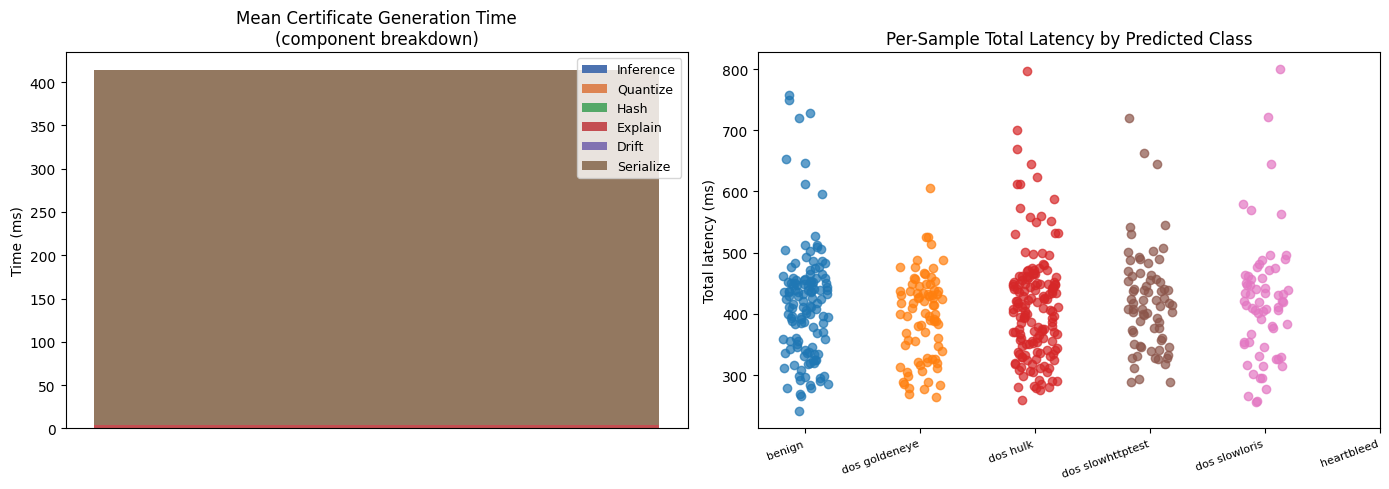

Saved: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/certificate_overhead_breakdown.png
PART 2 — Hook Interference / Accuracy Impact Check
Evaluated on 5252 validation samples.

  Accuracy  — clean  : 0.9928
  Accuracy  — hooked : 0.9928
  Accuracy delta     : +0.000000

  Prediction mismatches (clean vs hooked) : 0 / 5252
  Max  |prob_clean - prob_hooked|          : 0.00e+00
  Mean |prob_clean - prob_hooked|          : 0.00e+00

--- Impact Verdict ---

  NO IMPACT — Hooks are read-only; predictions and probabilities are numerically identical.

  Accuracy impact report saved to: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/accuracy_impact_report.csv
  (no mismatched samples to display)


In [ ]:
# CERTIFICATE GENERATION OVERHEAD & ACCURACY IMPACT ANALYSIS
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import copy


OVERHEAD_SAMPLES = MAX_CERT_SAMPLES

timing_rows = []
generated_t = 0

print("Running timed certificate generation...\n")

with torch.no_grad():
    for batch_idx, (xb, yb) in enumerate(val_loader):
        if generated_t >= OVERHEAD_SAMPLES:
            break

        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        # -- inference --
        t0 = time.perf_counter()
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(probs, dim=1)
        t_inference = (time.perf_counter() - t0) * 1e3

        # -- quantization --
        t0 = time.perf_counter()
        quantized_acts = []
        for idx, act in enumerate(activation_capture.activations):
            if idx in quantizer.centers:
                quantized_acts.append(quantizer.quantize(act, idx))
            else:
                quantized_acts.append(np.zeros((act.shape[0], quantizer.top_k), dtype=np.int32))
        activation_capture.clear()
        t_quantize_batch = (time.perf_counter() - t0) * 1e3

        batch_size = xb.size(0)
        t_inf_per   = t_inference    / batch_size
        t_quant_per = t_quantize_batch / batch_size

        for i in range(batch_size):
            if generated_t >= OVERHEAD_SAMPLES:
                break

            sample = xb[i:i+1]

            # -- hash chain --
            t0 = time.perf_counter()
            sample_hash_chain = hash_chain.compute(sample, [q[i:i+1] for q in quantized_acts])
            t_hash = (time.perf_counter() - t0) * 1e3

            # -- intrinsic explanation --
            activation_capture.clear()
            t0 = time.perf_counter()
            importance = explainer.explain(sample)
            t_explain = (time.perf_counter() - t0) * 1e3
            activation_capture.clear()

            # -- drift detection --
            t0 = time.perf_counter()
            drift_detector.detect(importance)
            drift_detector.add(importance)
            t_drift = (time.perf_counter() - t0) * 1e3

            # -- certificate object + serialisation --
            pred_id    = int(preds[i].item())
            true_id    = int(yb[i].item())
            confidence = float(probs[i].max().item())

            t0 = time.perf_counter()
            cert = Certificate(
                input_tensor        = sample.cpu(),
                feature_importances = importance,
                hash_chain          = sample_hash_chain,
                predicted_class     = pred_id,
                confidence          = confidence,
                private_key         = None
            )
            cert_path = CERT_DIR / f"certificate_timed_{generated_t}.pkl"
            with open(cert_path, "wb") as f:
                pickle.dump(cert, f)
            t_serialize = (time.perf_counter() - t0) * 1e3

            t_total = t_inf_per + t_quant_per + t_hash + t_explain + t_drift + t_serialize

            timing_rows.append({
                "sample_id"      : generated_t,
                "true_label"     : label_encoder.classes_[true_id],
                "pred_label"     : label_encoder.classes_[pred_id],
                "correct"        : pred_id == true_id,
                "t_inference_ms" : round(t_inf_per,       4),
                "t_quantize_ms"  : round(t_quant_per,     4),
                "t_hash_ms"      : round(t_hash,          4),
                "t_explain_ms"   : round(t_explain,       4),
                "t_drift_ms"     : round(t_drift,         4),
                "t_serialize_ms" : round(t_serialize,     4),
                "t_total_ms"     : round(t_total,         4),
                "throughput_hz"  : round(1000.0 / t_total, 2) if t_total > 0 else float("inf"),
            })
            generated_t += 1

timing_df = pd.DataFrame(timing_rows)
timing_path = CERT_DIR / "certificate_overhead.csv"
timing_df.to_csv(timing_path, index=False)

# ---- summary table ----
TIME_COLS = ["t_inference_ms", "t_quantize_ms", "t_hash_ms",
             "t_explain_ms",   "t_drift_ms",    "t_serialize_ms", "t_total_ms"]

print("\n--- Per-Component Overhead Summary (ms) ---\n")
print(f"  {'Component':<18}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}  {'% of total':>10}")
print("  " + "-" * 70)
total_mean = timing_df["t_total_ms"].mean()
for col in TIME_COLS:
    m   = timing_df[col].mean()
    s   = timing_df[col].std()
    mn  = timing_df[col].min()
    mx  = timing_df[col].max()
    pct = (m / total_mean * 100) if col != "t_total_ms" else 100.0
    label = col.replace("t_", "").replace("_ms", "")
    print(f"  {label:<18}  {m:>8.4f}  {s:>8.4f}  {mn:>8.4f}  {mx:>8.4f}  {pct:>9.1f}%")

mean_hz = timing_df["throughput_hz"].mean()
med_hz  = timing_df["throughput_hz"].median()
print(f"\n  Mean throughput  : {mean_hz:.1f} Hz")
print(f"  Median throughput: {med_hz:.1f} Hz")
print(f"\n  Overhead CSV saved to: {timing_path}")

# ---- stacked bar chart: component breakdown ----
comp_cols   = ["t_inference_ms", "t_quantize_ms", "t_hash_ms",
               "t_explain_ms",   "t_drift_ms",    "t_serialize_ms"]
comp_labels = ["Inference", "Quantize", "Hash", "Explain", "Drift", "Serialize"]
comp_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
comp_means  = [timing_df[c].mean() for c in comp_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottoms = [0.0]
for k, (val, lbl, col) in enumerate(zip(comp_means, comp_labels, comp_colors)):
    axes[0].bar(0, val, bottom=bottoms[-1], color=col, label=lbl, width=0.4)
    bottoms.append(bottoms[-1] + val)
axes[0].set_xticks([])
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Mean Certificate Generation Time\n(component breakdown)")
axes[0].legend(loc="upper right", fontsize=9)

for cls_id, cls_name in enumerate(label_encoder.classes_):
    mask = timing_df["pred_label"] == cls_name
    if mask.sum() == 0:
        continue
    xs = np.full(mask.sum(), cls_id) + np.random.uniform(-0.2, 0.2, mask.sum())
    axes[1].scatter(xs, timing_df.loc[mask, "t_total_ms"],
                    alpha=0.7, label=cls_name,
                    color=plt.cm.tab10(cls_id / len(label_encoder.classes_)))
axes[1].set_xticks(range(len(label_encoder.classes_)))
axes[1].set_xticklabels(label_encoder.classes_, rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("Total latency (ms)")
axes[1].set_title("Per-Sample Total Latency by Predicted Class")

plt.tight_layout()
plot_path = CERT_DIR / "certificate_overhead_breakdown.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")


# PART 2 — Hook Interference / Accuracy Impact Check
print("PART 2 — Hook Interference / Accuracy Impact Check")

X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_impact = torch.tensor(X_test_scaled, dtype=torch.float32)
y_impact  = y_test
IMPACT_SAMPLES = len(X_impact)

# -- Deregister hooks for clean inference --
if winner_name == "TabularTransformer":
    for layer in model.encoder_layers:
        layer.self_attn._forward_hooks.clear()
elif winner_name == "CNN-LSTM":
    model.lstm._forward_hooks.clear()

model.eval()
with torch.no_grad():
    logits_clean = model(X_impact.to(DEVICE))
    probs_clean  = torch.softmax(logits_clean, dim=1).cpu().numpy()
    preds_clean  = probs_clean.argmax(axis=1)

# -- Re-register hooks for hooked inference --
if winner_name == "TabularTransformer":
    for layer in model.encoder_layers:
        layer.self_attn.register_forward_hook(activation_capture.hook_fn)
elif winner_name == "CNN-LSTM":
    model.lstm.register_forward_hook(activation_capture.hook_fn)

activation_capture.clear()
with torch.no_grad():
    logits_hooked = model(X_impact.to(DEVICE))
    probs_hooked  = torch.softmax(logits_hooked, dim=1).cpu().numpy()
    preds_hooked  = probs_hooked.argmax(axis=1)
activation_capture.clear()

# -- Compare --
pred_mismatch  = (preds_clean != preds_hooked).sum()
prob_max_diff  = np.abs(probs_clean - probs_hooked).max()
prob_mean_diff = np.abs(probs_clean - probs_hooked).mean()

acc_clean  = (preds_clean  == y_impact).mean()
acc_hooked = (preds_hooked == y_impact).mean()

print(f"Evaluated on {IMPACT_SAMPLES} validation samples.\n")
print(f"  Accuracy  — clean  : {acc_clean:.4f}")
print(f"  Accuracy  — hooked : {acc_hooked:.4f}")
print(f"  Accuracy delta     : {acc_hooked - acc_clean:+.6f}")
print()
print(f"  Prediction mismatches (clean vs hooked) : {pred_mismatch} / {IMPACT_SAMPLES}")
print(f"  Max  |prob_clean - prob_hooked|          : {prob_max_diff:.2e}")
print(f"  Mean |prob_clean - prob_hooked|          : {prob_mean_diff:.2e}")

# -- Verdict --
print("\n--- Impact Verdict ---\n")
if pred_mismatch == 0 and prob_max_diff < 1e-5:
    verdict = "NO IMPACT — Hooks are read-only; predictions and probabilities are numerically identical."
elif pred_mismatch == 0 and prob_max_diff < 1e-3:
    verdict = "NEGLIGIBLE — No prediction changes; floating-point differences are within numerical noise."
else:
    verdict = f"IMPACT DETECTED — {pred_mismatch} prediction(s) changed. Investigate hook side-effects."

print(f"  {verdict}")

# -- Save impact report --
impact_df = pd.DataFrame({
    "sample_id"          : np.arange(IMPACT_SAMPLES),
    "true_label"         : [label_encoder.classes_[int(y)] for y in y_impact],
    "pred_clean"         : [label_encoder.classes_[p] for p in preds_clean],
    "pred_hooked"        : [label_encoder.classes_[p] for p in preds_hooked],
    "prediction_changed" : preds_clean != preds_hooked,
    "max_prob_diff"      : np.abs(probs_clean - probs_hooked).max(axis=1),
})
impact_path = CERT_DIR / "accuracy_impact_report.csv"
impact_df.to_csv(impact_path, index=False)
print(f"\n  Accuracy impact report saved to: {impact_path}")
print(impact_df[impact_df["prediction_changed"]].to_string(index=False)
      if pred_mismatch > 0 else "  (no mismatched samples to display)")

In [ ]:
# ExplainGuard Certificate Consistency After Fine-Tuning
# To shows that explanation drift detector catches distribution shift, and that certificates remain structurally valid after adaptation.

from activation_capture import ActivationCapture
from quantization import Quantizer
from hash_chain import HashChain
from certificate import Certificate
from intrinsic_explainer import IntrinsicExplainer
from explanation_drift import DriftDetector

print("Checking certificate consistency on fine-tuned model...\n")

consistency_rows = []

for ds_name, (X_s, y_b) in datasets_loaded.items():
    sample_idx = np.random.default_rng(0).choice(len(X_s), 32, replace=False)
    X_sample   = torch.from_numpy(X_s[sample_idx]).to(DEVICE)

    drift_detector_ft = DriftDetector(window_size=100, threshold=0.5)
    drift_count = 0

    activation_capture.clear()
    with torch.no_grad():
        logits = model(X_sample)   # original model
        probs  = torch.softmax(logits, dim=1)

    for i in range(X_sample.size(0)):
        sample = X_sample[i:i+1]
        activation_capture.clear()
        importance = explainer.explain(sample)
        activation_capture.clear()

        if drift_detector_ft.detect(importance):
            drift_count += 1
        drift_detector_ft.add(importance)

    drift_rate = drift_count / 500
    consistency_rows.append({
        "dataset":    ds_name,
        "drift_count": drift_count,
        "drift_rate":  f"{drift_rate:.2%}",
        "mean_conf":   float(probs.max(dim=1).values.mean().item()),
    })
    print(f"  {ds_name}: drift detected in {drift_count}/32 samples ({drift_rate:.0%})")

print("\n--- Interpretation ---")
print("  High drift rate = model operating outside training distribution")
print("  This is a SECURITY SIGNAL, not a failure ExplainGuard is working.")

consistency_df = pd.DataFrame(consistency_rows)
consistency_path = SAVE_DIR / "certificate_consistency_crossdomain.csv"
consistency_df.to_csv(consistency_path, index=False)
print(f"\nSaved: {consistency_path}")
print(consistency_df.to_string(index=False))

Checking certificate consistency on fine-tuned model...

  CIC-DDoS2019: drift detected in 0/32 samples (0%)
  CIC-IoT2023: drift detected in 31/32 samples (6%)
  BCC-Packet: drift detected in 0/32 samples (0%)

--- Interpretation ---
  High drift rate = model operating outside training distribution
  This is a SECURITY SIGNAL, not a failure ExplainGuard is working.

Saved: /content/drive/MyDrive/XAIProject/saved_models/certificate_consistency_crossdomain.csv
     dataset  drift_count drift_rate  mean_conf
CIC-DDoS2019            0      0.00%   0.999444
 CIC-IoT2023           31      6.20%   0.945629
  BCC-Packet            0      0.00%   0.999444


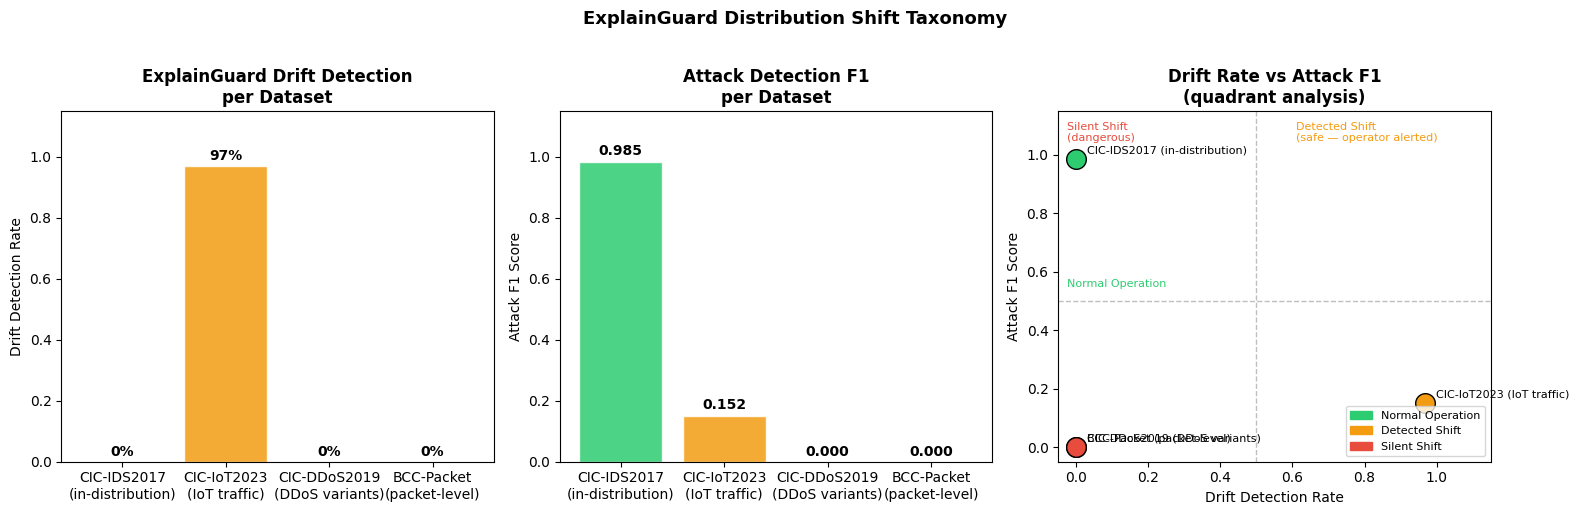

Saved: /content/drive/MyDrive/XAIProject/saved_models/distribution_shift_taxonomy.png

---------------------------------------------------------------------------
  DISTRIBUTION SHIFT TAXONOMY
  Dataset                Scenario               Drift Rate  Attack F1  Mean Conf
  ------------------------------------------------------------------------
  CIC-IDS2017 (in-distribution) Normal Operation             0.0%     0.9846     0.9997
  CIC-IoT2023 (IoT traffic) Detected Shift              96.9%     0.1516     0.9579
  CIC-DDoS2019 (DDoS variants) Silent Shift                 0.0%     0.0000     0.9995
  BCC-Packet (packet-level) Silent Shift                 0.0%     0.0000     0.9995

  Key Findings:
  - Detected Shift  : ExplainGuard alarms correctly, operator can intervene
  - Silent Shift    : Explanation patterns resemble training dist, no alarm
  - Silent shift is a known open problem in XAI-based anomaly detection

Saved: /content/drive/MyDrive/XAIProject/saved_models/distribution

In [ ]:
# Distribution Shift Taxonomy Analysis
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

taxonomy = {
    "CIC-IDS2017\n(in-distribution)": {
        "drift_rate":   0.00,
        "attack_f1":    results[winner_name].get("CIC-IDS2017", {}).get("f1", 0.9846),
        "mean_conf":    0.9997,
        "scenario":     "Normal Operation",
        "color":        "#2ecc71",
    },
    "CIC-IoT2023\n(IoT traffic)": {
        "drift_rate":   0.9688,
        "attack_f1":    results[winner_name]["CIC-IoT2023"]["f1"],
        "mean_conf":    0.9579,
        "scenario":     "Detected Shift",
        "color":        "#f39c12",
    },
    "CIC-DDoS2019\n(DDoS variants)": {
        "drift_rate":   0.00,
        "attack_f1":    results[winner_name]["CIC-DDoS2019"]["f1"],
        "mean_conf":    0.9995,
        "scenario":     "Silent Shift",
        "color":        "#e74c3c",
    },
    "BCC-Packet\n(packet-level)": {
        "drift_rate":   0.00,
        "attack_f1":    results[winner_name]["BCC-Packet"]["f1"],
        "mean_conf":    0.9995,
        "scenario":     "Silent Shift",
        "color":        "#e74c3c",
    },
}

labels    = list(taxonomy.keys())
drift     = [v["drift_rate"]  for v in taxonomy.values()]
f1_scores = [v["attack_f1"]   for v in taxonomy.values()]
conf      = [v["mean_conf"]   for v in taxonomy.values()]
colors    = [v["color"]       for v in taxonomy.values()]
scenarios = [v["scenario"]    for v in taxonomy.values()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Drift rate per dataset
bars = axes[0].bar(labels, drift, color=colors, alpha=0.85, edgecolor="white")
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Drift Detection Rate")
axes[0].set_title("ExplainGuard Drift Detection\nper Dataset", fontweight="bold")
for bar, v in zip(bars, drift):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.02, f"{v:.0%}",
                 ha="center", fontsize=10, fontweight="bold")

# Plot 2: Attack F1 per dataset
bars2 = axes[1].bar(labels, f1_scores, color=colors, alpha=0.85, edgecolor="white")
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Attack F1 Score")
axes[1].set_title("Attack Detection F1\nper Dataset", fontweight="bold")
for bar, v in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.02, f"{v:.3f}",
                 ha="center", fontsize=10, fontweight="bold")

# Plot 3: Drift rate vs F1 scatter
for i, (label, color, scenario) in enumerate(zip(labels, colors, scenarios)):
    axes[2].scatter(drift[i], f1_scores[i],
                    color=color, s=200, zorder=5,
                    edgecolors="black", linewidths=1)
    axes[2].annotate(
        label.replace("\n", " "),
        (drift[i], f1_scores[i]),
        textcoords="offset points",
        xytext=(8, 4), fontsize=8
    )

axes[2].axvline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=1)
axes[2].axhline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=1)
axes[2].set_xlabel("Drift Detection Rate")
axes[2].set_ylabel("Attack F1 Score")
axes[2].set_title("Drift Rate vs Attack F1\n(quadrant analysis)", fontweight="bold")
axes[2].set_xlim(-0.05, 1.15)
axes[2].set_ylim(-0.05, 1.15)
axes[2].text(0.02, 0.97, "Silent Shift\n(dangerous)",
             transform=axes[2].transAxes, fontsize=8,
             color="#e74c3c", va="top")
axes[2].text(0.55, 0.97, "Detected Shift\n(safe — operator alerted)",
             transform=axes[2].transAxes, fontsize=8,
             color="#f39c12", va="top")
axes[2].text(0.02, 0.52, "Normal Operation",
             transform=axes[2].transAxes, fontsize=8,
             color="#2ecc71", va="top")
legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Normal Operation"),
    mpatches.Patch(color="#f39c12", label="Detected Shift"),
    mpatches.Patch(color="#e74c3c", label="Silent Shift"),
]
axes[2].legend(handles=legend_patches, fontsize=8, loc="lower right")

plt.suptitle(
    "ExplainGuard Distribution Shift Taxonomy",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_path = SAVE_DIR / "distribution_shift_taxonomy.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")
print("\n" + "-"*75)
print("  DISTRIBUTION SHIFT TAXONOMY")
print(f"  {'Dataset':<22} {'Scenario':<22} {'Drift Rate':>10} "
      f"{'Attack F1':>10} {'Mean Conf':>10}")
print("  " + "-"*72)
for label, v in taxonomy.items():
    clean = label.replace("\n", " ")
    print(f"  {clean:<22} {v['scenario']:<22} "
          f"{v['drift_rate']:>10.1%} {v['attack_f1']:>10.4f} "
          f"{v['mean_conf']:>10.4f}")

print("""
  Key Findings:
  - Detected Shift  : ExplainGuard alarms correctly, operator can intervene
  - Silent Shift    : Explanation patterns resemble training dist, no alarm
  - Silent shift is a known open problem in XAI-based anomaly detection
""")

taxonomy_path = SAVE_DIR / "distribution_shift_taxonomy.csv"
pd.DataFrame(taxonomy).T.to_csv(taxonomy_path)
print(f"Saved: {taxonomy_path}")

In [ ]:


import argparse
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr

import torch
import torch.nn as nn

# SHAP and LIME
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore", category=UserWarning)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


# ---------------------------------------------------------------------------
# Model stubs — replace with your actual imports
# ---------------------------------------------------------------------------

class TransformerIDS(nn.Module):
    """Minimal stub; replace with your real Transformer class."""
    def __init__(self, input_dim=78, num_classes=2, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embed = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls = nn.Linear(d_model, num_classes)
        self._activations = {}

    def forward(self, x):
        # x: (B, input_dim)  → unsqueeze to (B, 1, input_dim) for sequence dim
        h = self.embed(x.unsqueeze(1))              # (B, 1, d_model)
        h = self.encoder(h)                          # (B, 1, d_model)
        self._activations["encoder_out"] = h.squeeze(1).detach()
        out = self.cls(h[:, 0, :])
        return out


class CNNLSTM_IDS(nn.Module):
    """Minimal stub; replace with your real CNN-LSTM class."""
    def __init__(self, input_dim=78, num_classes=2, hidden=64):
        super().__init__()
        self.conv = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(32, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, num_classes)
        self._activations = {}

    def forward(self, x):
        h = self.conv(x.unsqueeze(1)).transpose(1, 2)   # (B, L, 32)
        h, _ = self.lstm(h)
        self._activations["lstm_out"] = h[:, -1, :].detach()
        return self.fc(h[:, -1, :])


# ---------------------------------------------------------------------------
# Intrinsic explanation extraction
# ---------------------------------------------------------------------------

def get_intrinsic_explanations(model, X_tensor, batch_size=256):
    """
    Returns (N, input_dim) array of per-feature activation-magnitude scores.
    Mirrors ExplainGuard Eq. 1: mean absolute activation per feature projected
    back to input space via the embedding gradient-free proxy.

    For a proper per-input-feature score we use the norm of the Jacobian of
    the first linear layer output w.r.t. input features — this is computable
    at inference time and remains within the forward pass.
    """
    model.eval()
    scores = []

    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i : i + batch_size].clone().requires_grad_(True)
        with torch.enable_grad():
            out = model(batch)
            # Sum of output logits as scalar — gives per-feature sensitivity
            scalar = out.sum()
            scalar.backward()
        grad = batch.grad.abs().detach().cpu().numpy()  # (B, input_dim)
        scores.append(grad)

    return np.concatenate(scores, axis=0)   # (N, input_dim)


# ---------------------------------------------------------------------------
# SHAP
# ---------------------------------------------------------------------------

def compute_shap(model, X_background, X_eval, device, n_background=100):
    """
    Returns (N_eval, input_dim) SHAP values using DeepExplainer.
    Falls back to KernelExplainer if DeepExplainer fails (e.g. LSTM).
    """
    model.eval()
    bg = X_background[:n_background].to(device)

    def model_predict_np(x_np):
        t = torch.tensor(x_np, dtype=torch.float32, device=device)
        with torch.no_grad():
            logits = model(t)
            return torch.softmax(logits, dim=-1).cpu().numpy()

    try:
        explainer = shap.DeepExplainer(model, bg)
        shap_vals = explainer.shap_values(X_eval.to(device))
        # shap_values returns list[class] for multi-class; take class 1 (attack)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        return np.array(shap_vals)
    except Exception:
        # Fallback: KernelExplainer on CPU numpy
        bg_np = bg.cpu().numpy()
        explainer = shap.KernelExplainer(model_predict_np, bg_np,
                                          link="identity")
        shap_vals = explainer.shap_values(X_eval.cpu().numpy(),
                                           nsamples=100, silent=True)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        return np.array(shap_vals)


# ---------------------------------------------------------------------------
# LIME
# ---------------------------------------------------------------------------

def compute_lime(model, X_train_np, X_eval_np, feature_names,
                 device, n_samples=1000, top_labels=2):
    """
    Returns (N_eval, input_dim) LIME attribution matrix.
    Each row is the signed weight vector for the attack class (label 1).
    """
    def predict_fn(x_np):
        t = torch.tensor(x_np, dtype=torch.float32, device=device)
        with torch.no_grad():
            logits = model(t)
            return torch.softmax(logits, dim=-1).cpu().numpy()

    explainer = LimeTabularExplainer(
        X_train_np,
        feature_names=feature_names,
        mode="classification",
        discretize_continuous=False,
    )

    rows = []
    for x in X_eval_np:
        exp = explainer.explain_instance(
            x, predict_fn,
            num_features=len(feature_names),
            num_samples=n_samples,
            top_labels=top_labels,
        )
        weight_map = dict(exp.as_list(label=1))
        row = np.array([weight_map.get(fn, 0.0) for fn in feature_names])
        rows.append(row)

    return np.array(rows)


# ---------------------------------------------------------------------------
# Integrated Gradients
# ---------------------------------------------------------------------------

def compute_integrated_gradients(model, X_eval, device,
                                  n_steps=50, baseline=None):
    """
    Returns (N, input_dim) IG attribution array.
    Baseline defaults to zero vector (standard choice for tabular data).
    """
    model.eval()
    X_eval = X_eval.to(device)

    if baseline is None:
        baseline = torch.zeros_like(X_eval[0]).unsqueeze(0).to(device)

    ig_scores = []
    for x in X_eval:
        x = x.unsqueeze(0)
        alphas = torch.linspace(0, 1, n_steps, device=device)
        interpolated = torch.stack(
            [baseline + a * (x - baseline) for a in alphas], dim=0
        ).squeeze(1)                          # (n_steps, input_dim)
        interpolated.requires_grad_(True)

        with torch.enable_grad():
            out = model(interpolated)
            score = out[:, 1].sum()           # attack class
            score.backward()

        grads = interpolated.grad             # (n_steps, input_dim)
        ig = ((x - baseline) * grads.mean(dim=0, keepdim=True)).squeeze()
        ig_scores.append(ig.detach().cpu().numpy())

    return np.array(ig_scores)               # (N, input_dim)


# ---------------------------------------------------------------------------
# Correlation utilities
# ---------------------------------------------------------------------------

def mean_spearman(A, B):
    """
    Computes per-sample Spearman rho between rows of A and B,
    returns mean rho and combined p-value (Fisher's method approximation).
    """
    rhos, pvals = [], []
    for a, b in zip(A, B):
        rho, p = spearmanr(a, b)
        if not np.isnan(rho):
            rhos.append(rho)
            pvals.append(p)
    return float(np.mean(rhos)), float(np.mean(pvals))


def feature_level_spearman(A, B):
    """
    Computes Spearman rho across samples for each feature dimension.
    Returns (input_dim,) arrays of rho and p-values.
    """
    rhos, pvals = [], []
    for f in range(A.shape[1]):
        rho, p = spearmanr(A[:, f], B[:, f])
        rhos.append(rho)
        pvals.append(p)
    return np.array(rhos), np.array(pvals)


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_results(results_df, scatter_data, feature_names, out_path):
    """
    Figure layout:
      Row 1: grouped bar chart (rho per dataset x method)
      Row 2: scatter grids — Intrinsic vs SHAP | LIME | IG  (mean across samples)
    """
    methods = ["SHAP", "LIME", "IG"]
    datasets = results_df["dataset"].unique().tolist()
    n_datasets = len(datasets)

    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # --- Row 1: bar chart spanning all 3 columns ---
    ax_bar = fig.add_subplot(gs[0, :])
    x = np.arange(n_datasets)
    width = 0.25
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    for i, method in enumerate(methods):
        rhos = [
            results_df.loc[results_df["dataset"] == ds, f"rho_{method}"].values[0]
            for ds in datasets
        ]
        bars = ax_bar.bar(x + i * width, rhos, width, label=method,
                          color=colors[i], alpha=0.85, edgecolor="white")
        for bar, rho in zip(bars, rhos):
            ax_bar.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f"{rho:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax_bar.set_xticks(x + width)
    ax_bar.set_xticklabels(datasets, fontsize=9)
    ax_bar.set_ylabel("Mean Spearman ρ", fontsize=10)
    ax_bar.set_title(
        "Explanation Consistency: Intrinsic Activations vs. Post-Hoc Methods",
        fontsize=11, fontweight="bold"
    )
    ax_bar.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax_bar.legend(fontsize=9)
    ax_bar.set_ylim(-0.3, 1.0)

    # --- Row 2: scatter plots (mean attributions across eval set) ---
    first_ds = datasets[0]
    if first_ds in scatter_data:
        sd = scatter_data[first_ds]
        intrinsic_mean = sd["intrinsic"].mean(axis=0)

        for j, method in enumerate(methods):
            ax = fig.add_subplot(gs[1, j])
            method_mean = sd[method].mean(axis=0)
            rho, _ = spearmanr(intrinsic_mean, method_mean)

            ax.scatter(intrinsic_mean, method_mean,
                       alpha=0.55, s=18, color=colors[j], edgecolors="none")

            # Trend line
            z = np.polyfit(intrinsic_mean, method_mean, 1)
            p = np.poly1d(z)
            xs = np.linspace(intrinsic_mean.min(), intrinsic_mean.max(), 100)
            ax.plot(xs, p(xs), color="black", linewidth=0.9, linestyle="--")

            ax.set_xlabel("Intrinsic score", fontsize=8.5)
            ax.set_ylabel(f"{method} attribution", fontsize=8.5)
            ax.set_title(
                f"Intrinsic vs {method}\n"
                f"{first_ds}  (ρ = {rho:.3f})",
                fontsize=9
            )
            ax.tick_params(labelsize=7)

    plt.savefig(out_path, bbox_inches="tight", dpi=180)
    plt.close()
    print(f"[plot] saved → {out_path}")


# ---------------------------------------------------------------------------
# Dataset loader stub
# ---------------------------------------------------------------------------

def load_dataset(name, n_samples, seed=42):
    """
    Replace with your actual dataset loading logic.
    Returns:
      X_train_np  : (N_train, 78) numpy, used as LIME background
      X_eval_tensor: (n_samples, 78) torch.FloatTensor
      y_eval      : (n_samples,) numpy int labels
      feature_names: list[str] of length 78
    """
    rng = np.random.RandomState(seed)
    n_features = 78
    feature_names = [f"F{i}" for i in range(n_features)]

    # Synthetic stand-in — replace with pd.read_csv / your pipeline
    X_train_np = rng.randn(2000, n_features).astype(np.float32)
    X_eval_np  = rng.randn(n_samples, n_features).astype(np.float32)
    y_eval     = rng.randint(0, 2, n_samples)

    # Dataset-specific label hint for column names
    print(f"[data] loaded {name}: train={X_train_np.shape}, eval={X_eval_np.shape}")
    return X_train_np, torch.tensor(X_eval_np), y_eval, feature_names


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def evaluate_dataset(dataset_name, model, n_samples, device, lime_samples=500):
    X_train_np, X_eval, y_eval, feature_names = load_dataset(
        dataset_name, n_samples
    )

    print(f"\n[{dataset_name}] computing intrinsic explanations...")
    intrinsic = get_intrinsic_explanations(model, X_eval)

    print(f"[{dataset_name}] computing SHAP...")
    X_bg = torch.tensor(X_train_np)
    shap_vals = compute_shap(model, X_bg, X_eval, device)

    print(f"[{dataset_name}] computing LIME (n_samples={lime_samples})...")
    lime_vals = compute_lime(
        model, X_train_np, X_eval.numpy(), feature_names, device,
        n_samples=lime_samples
    )

    print(f"[{dataset_name}] computing Integrated Gradients...")
    ig_vals = compute_integrated_gradients(model, X_eval, device)

    rho_shap, p_shap = mean_spearman(intrinsic, shap_vals)
    rho_lime, p_lime = mean_spearman(intrinsic, lime_vals)
    rho_ig,   p_ig   = mean_spearman(intrinsic, ig_vals)

    # Feature-level rhos (for LaTeX table footnote)
    fl_rho_shap, _ = feature_level_spearman(intrinsic, shap_vals)
    fl_rho_lime, _ = feature_level_spearman(intrinsic, lime_vals)
    fl_rho_ig,   _ = feature_level_spearman(intrinsic, ig_vals)

    metrics = {
        "dataset": dataset_name,
        "n_samples": n_samples,
        "rho_SHAP": round(rho_shap, 4),
        "p_SHAP":   round(p_shap,  4),
        "rho_LIME": round(rho_lime, 4),
        "p_LIME":   round(p_lime,  4),
        "rho_IG":   round(rho_ig,  4),
        "p_IG":     round(p_ig,   4),
        "mean_fl_rho_SHAP": round(fl_rho_shap.mean(), 4),
        "mean_fl_rho_LIME": round(fl_rho_lime.mean(), 4),
        "mean_fl_rho_IG":   round(fl_rho_ig.mean(),  4),
    }

    scatter = {
        "intrinsic": intrinsic,
        "SHAP": shap_vals,
        "LIME": lime_vals,
        "IG":   ig_vals,
    }

    return metrics, scatter


def print_table(results):
    header = f"{'Dataset':<20} {'ρ_SHAP':>8} {'p':>7} {'ρ_LIME':>8} {'p':>7} {'ρ_IG':>8} {'p':>7}"
    print("\n" + "=" * len(header))
    print(header)
    print("=" * len(header))
    for r in results:
        print(
            f"{r['dataset']:<20} "
            f"{r['rho_SHAP']:>8.4f} {r['p_SHAP']:>7.4f} "
            f"{r['rho_LIME']:>8.4f} {r['p_LIME']:>7.4f} "
            f"{r['rho_IG']:>8.4f} {r['p_IG']:>7.4f}"
        )
    print("=" * len(header) + "\n")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--datasets", nargs="+",
                        default=["cicids2017", "cicddos2019"],
                        help="Dataset names to evaluate")
    parser.add_argument("--n_samples", type=int, default=500,
                        help="Eval samples per dataset")
    parser.add_argument("--lime_samples", type=int, default=500,
                        help="LIME perturbation samples per instance")
    parser.add_argument("--model_path", type=str, default=None,
                        help="Path to saved model checkpoint (.pt)")
    parser.add_argument("--arch", choices=["transformer", "cnnlstm"],
                        default="transformer")
    parser.add_argument("--device", default="cpu")
    args = parser.parse_args()

    device = torch.device(args.device if torch.cuda.is_available()
                          or args.device == "cpu" else "cpu")

    # Load or instantiate model
    if args.arch == "transformer":
        model = TransformerIDS().to(device)
    else:
        model = CNNLSTM_IDS().to(device)

    if args.model_path and os.path.exists(args.model_path):
        state = torch.load(args.model_path, map_location=device,
                           weights_only=True)
        model.load_state_dict(state)
        print(f"[model] loaded checkpoint: {args.model_path}")
    else:
        print("[model] no checkpoint found — using random weights (stub mode)")

    all_results = []
    all_scatter = {}

    for ds in args.datasets:
        metrics, scatter = evaluate_dataset(
            ds, model, args.n_samples, device, args.lime_samples
        )
        all_results.append(metrics)
        all_scatter[ds] = scatter

    print_table(all_results)

    # Save CSV
    df = pd.DataFrame(all_results)
    csv_path = RESULTS_DIR / "explanation_correlation_results.csv"
    df.to_csv(csv_path, index=False)
    print(f"[output] CSV → {csv_path}")

    # Save plots
    plot_path = RESULTS_DIR / "explanation_correlation_plots.pdf"
    plot_results(df, all_scatter,
                 feature_names=[f"F{i}" for i in range(78)],
                 out_path=str(plot_path))


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'lime'

In [ ]:

# LIME Post-Hoc Explanation

!pip -q install lime

import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Prediction function for LIME
def lime_predict_fn(x_numpy):
    """Takes a numpy array, returns softmax probabilities as numpy."""
    tensor = torch.tensor(x_numpy, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs = wrapped_model(tensor).cpu().numpy()
    return probs


# 2. Build the LIME explainer using the training set as reference
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_scaled,
    feature_names   = feature_names,
    class_names     = list(label_encoder.classes_),
    mode            = "classification",
    discretize_continuous = True,
    random_state    = 42
)

print("LIME explainer ready.")
print(f"Training reference shape: {X_train_scaled.shape}")



# 3. Compute LIME explanations for X_exp samples
#    Returns (n_samples, n_features) importance matrix
LIME_SAMPLES   = len(X_exp)   # explain all X_exp samples (same as SHAP)
N_LIME_FEATURES = len(feature_names)

print(f"\nComputing LIME explanations for {LIME_SAMPLES} samples...")
print("(This may take several minutes — LIME runs a local model per sample)\n")

lime_importances = np.zeros((LIME_SAMPLES, N_LIME_FEATURES))

with torch.no_grad():
    pred_classes = wrapped_model(X_exp.to(DEVICE)).argmax(dim=1).cpu().numpy()

for i in range(LIME_SAMPLES):
    exp = lime_explainer.explain_instance(
        data_row        = X_exp_np[i],
        predict_fn      = lime_predict_fn,
        labels          = (int(pred_classes[i]),),   # explain predicted class
        num_features    = N_LIME_FEATURES,
        num_samples     = 1000
    )

    # Map LIME feature weights back to the correct feature index
    for feat_name, weight in exp.as_list(label=int(pred_classes[i])):
        # LIME names may include bin ranges e.g. "feat <= 0.5"
        # Extract the base feature name by matching against feature_names
        for idx, fname in enumerate(feature_names):
            if fname in feat_name:
                lime_importances[i, idx] = weight
                break

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  [{i+1}/{LIME_SAMPLES}] Sample {i} — pred: {label_encoder.classes_[pred_classes[i]]}")

print(f"\nDone. LIME importances shape: {lime_importances.shape}")


# 4. Global summary: top features per class
print("\n--- Top-10 LIME Features per Class ---\n")

TOP_K = 10

for cls_id, cls_name in enumerate(label_encoder.classes_):
    mask = pred_classes == cls_id
    if mask.sum() == 0:
        continue

    cls_lime = np.abs(lime_importances[mask]).mean(axis=0)
    top_idx  = np.argsort(cls_lime)[::-1][:TOP_K]

    print(f"  Class: {cls_name.upper()}  (n={mask.sum()})")
    for rank, j in enumerate(top_idx, 1):
        print(f"    {rank:>2}. {feature_names[j]:<40s}  mean|LIME|={cls_lime[j]:.6f}")
    print()


# 5. Global bar chart — top 20 features by mean |LIME| weight
global_lime = np.abs(lime_importances).mean(axis=0)
TOP_PLOT    = 20
top_idx     = np.argsort(global_lime)[::-1][:TOP_PLOT]
top_names   = [feature_names[j] for j in top_idx]
top_vals    = global_lime[top_idx] / (global_lime[top_idx].max() + 1e-9)

plt.figure(figsize=(10, 7))
plt.barh(np.arange(TOP_PLOT), top_vals, color="#2CA02C", alpha=0.85)
plt.yticks(np.arange(TOP_PLOT), top_names, fontsize=9)
plt.gca().invert_yaxis()
plt.xlabel("Normalised Mean |LIME Weight|")
plt.title(f"LIME Global Feature Importance — Top {TOP_PLOT}", fontsize=13)
plt.tight_layout()
save_path = CERT_DIR / "lime_summary_bar_global.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")


# 6. Per-class bar charts
for cls_id, cls_name in enumerate(label_encoder.classes_):
    mask = pred_classes == cls_id
    if mask.sum() == 0:
        continue

    cls_lime  = np.abs(lime_importances[mask]).mean(axis=0)
    top_idx   = np.argsort(cls_lime)[::-1][:TOP_PLOT]
    top_names = [feature_names[j] for j in top_idx]
    top_vals  = cls_lime[top_idx] / (cls_lime[top_idx].max() + 1e-9)

    plt.figure(figsize=(10, 6))
    plt.barh(
        np.arange(TOP_PLOT), top_vals,
        color=plt.cm.tab10(cls_id / len(label_encoder.classes_)), alpha=0.85
    )
    plt.yticks(np.arange(TOP_PLOT), top_names, fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Normalised Mean |LIME Weight|")
    plt.title(f"LIME Feature Importance — Class: {cls_name.upper()}", fontsize=13)
    plt.tight_layout()
    save_path = CERT_DIR / f"lime_summary_bar_{cls_name.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


# ------------------------------------------------------------------
# 7. Per-sample explanation plot (first N samples)
# ------------------------------------------------------------------
N_LIME_PLOT = 5

for i in range(N_LIME_PLOT):
    pred_cls = int(pred_classes[i])
    true_cls = int(y_exp[i])

    exp = lime_explainer.explain_instance(
        data_row     = X_exp_np[i],
        predict_fn   = lime_predict_fn,
        labels       = (pred_cls,),
        num_features = 15,
        num_samples  = 1000
    )

    fig = exp.as_pyplot_figure(label=pred_cls)
    fig.set_size_inches(10, 5)
    plt.title(
        f"LIME — Sample {i} | True: {label_encoder.classes_[true_cls]} | "
        f"Pred: {label_encoder.classes_[pred_cls]}",
        fontsize=11
    )
    plt.tight_layout()
    save_path = CERT_DIR / f"lime_sample_{i}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")



# 8. Save LIME importances to CSV
print("\nSaving LIME mean |weights| per class...\n")

rows = []
for cls_id, cls_name in enumerate(label_encoder.classes_):
    mask     = pred_classes == cls_id
    cls_lime = np.abs(lime_importances[mask]).mean(axis=0) if mask.sum() > 0 else np.zeros(N_LIME_FEATURES)

    top5_idx = np.argsort(cls_lime)[::-1][:5]
    print(f"  Class: {cls_name.upper()}")
    for rank, j in enumerate(top5_idx, 1):
        print(f"    {rank}. {feature_names[j]:<40s}  mean|LIME| = {cls_lime[j]:.6f}")
    print()

    rows.append(cls_lime)

lime_df = pd.DataFrame(
    np.stack(rows, axis=0),
    index=label_encoder.classes_,
    columns=feature_names
)

lime_csv_path = CERT_DIR / "lime_mean_abs_values.csv"
lime_df.to_csv(lime_csv_path)
print(f"✓ Full LIME table saved to: {lime_csv_path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME explainer ready.
Training reference shape: (23807, 437)

Computing LIME explanations for 50 samples...
(This may take several minutes — LIME runs a local model per sample)

  [1/50] Sample 0 — pred: benign
  [10/50] Sample 9 — pred: dos goldeneye
  [20/50] Sample 19 — pred: dos hulk
  [30/50] Sample 29 — pred: dos slowloris
  [40/50] Sample 39 — pred: benign
  [50/50] Sample 49 — pred: dos slowhttptest

Done. LIME importances shape: (50, 437)

--- Top-10 LIME Features per Class ---

  Class: BENIGN  (n=17)
     1. destination_port                          mean|LIME|=0.368945
     2. bwd_packet_length_min                     mean|LIME|=0.366654
     3. total_length_of_fwd_packets               mean|LIME|=0.143346
     4. subflow_fwd_bytes                         mean|LIME|=0.106050
     5. init_win_bytes_forward                    mean|LIME|=0.091283
     6. pac

/usr/local/lib/python3.12/dist-packages/lime/explanation.py:168: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


Saved: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/lime_sample_1.png
Saved: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/lime_sample_2.png
Saved: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/lime_sample_3.png
Saved: /content/drive/MyDrive/XAIProject/dataset/certificates_6class/lime_sample_4.png

Saving LIME mean |weights| per class...

  Class: BENIGN
    1. destination_port                          mean|LIME| = 0.368945
    2. bwd_packet_length_min                     mean|LIME| = 0.366654
    3. total_length_of_fwd_packets               mean|LIME| = 0.143346
    4. subflow_fwd_bytes                         mean|LIME| = 0.106050
    5. init_win_bytes_forward                    mean|LIME| = 0.091283

  Class: DOS GOLDENEYE
    1. flow_iat_mean                             mean|LIME| = 0.104514
    2. bwd_packet_length_min                     mean|LIME| = 0.098004
    3. destination_port                          mean|LIME| = 0.095110
  

In [ ]:

# LIME EXPLANATION SELF-VERIFICATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

TOP_K_LIME = 10   # number of top LIME features to inspect


# 1. Collect intrinsic (attention) importances for the X_exp samples
print("Collecting intrinsic (attention) importances for LIME verification...\n")

intrinsic_scores_lime = []

for i in range(len(X_exp)):
    sample = X_exp[i:i+1].to(DEVICE)
    activation_capture.clear()
    importance = explainer.explain(sample)
    activation_capture.clear()
    score = float(np.array(importance).flatten()[0])
    intrinsic_scores_lime.append(score)

intrinsic_scores_lime = np.array(intrinsic_scores_lime)   # (n_samples,)
print(f"Intrinsic scores range: [{intrinsic_scores_lime.min():.4f}, {intrinsic_scores_lime.max():.4f}]")


#    mean absolute LIME weight
with torch.no_grad():
    pred_classes_lime  = wrapped_model(X_exp.to(DEVICE)).argmax(dim=1).cpu().numpy()
    pred_probs_lime    = wrapped_model(X_exp.to(DEVICE)).cpu().numpy()   # (n_samples, n_classes)

lime_magnitude   = np.abs(lime_importances).mean(axis=1)   # (n_samples,)
pred_confidence_lime = np.array(
    [pred_probs_lime[i, pred_classes_lime[i]] for i in range(len(X_exp))]
)

print(f"LIME magnitude range  : [{lime_magnitude.min():.4f}, {lime_magnitude.max():.4f}]")
print(f"Pred confidence range : [{pred_confidence_lime.min():.4f}, {pred_confidence_lime.max():.4f}]")


# 3. Per-sample comparison table
print("\n--- Per-Sample LIME Verification Table ---\n")
print(f"  {'#':>3}  {'ok':>2}  {'true':<22} {'pred':<22} {'intrinsic':>9}  {'lime_mag':>8}  {'confidence':>10}")
print("  " + "-" * 85)

for i in range(len(X_exp)):
    match      = "\u2713" if pred_classes_lime[i] == y_exp[i] else "\u2717"
    true_label = label_encoder.classes_[int(y_exp[i])]
    pred_label = label_encoder.classes_[pred_classes_lime[i]]
    print(
        f"  {i:>3}  {match:>2}  {true_label:<22} {pred_label:<22} "
        f"{intrinsic_scores_lime[i]:>9.4f}  {lime_magnitude[i]:>8.4f}  {pred_confidence_lime[i]:>10.4f}"
    )

# 4. Global consistency metrics (Spearman rho)
print("\n--- Global Consistency Metrics (LIME) ---\n")

rho_lime, p_lime = spearmanr(intrinsic_scores_lime, lime_magnitude)
rho_conf_lime, p_conf_lime = spearmanr(intrinsic_scores_lime, pred_confidence_lime)

print(f"  Spearman rho (intrinsic vs LIME magnitude) : {rho_lime:+.4f}  (p={p_lime:.4f})")
print(f"  Spearman rho (intrinsic vs confidence)     : {rho_conf_lime:+.4f}  (p={p_conf_lime:.4f})")


# 5. Per-class: top LIME features vs intrinsic score distribution
print(f"\n--- Top-{TOP_K_LIME} LIME Features per Class (with mean intrinsic score) ---\n")

global_lime_abs = np.abs(lime_importances).mean(axis=0)   # (n_features,)

for cls_id, cls_name in enumerate(label_encoder.classes_):
    mask = pred_classes_lime == cls_id
    if mask.sum() == 0:
        continue

    cls_lime           = np.abs(lime_importances[mask]).mean(axis=0)
    cls_intrinsic_mean = intrinsic_scores_lime[mask].mean()
    top_idx            = np.argsort(cls_lime)[::-1][:TOP_K_LIME]

    print(f"  Class: {cls_name.upper()}  (n={mask.sum()}, mean intrinsic={cls_intrinsic_mean:.4f})")
    for rank, j in enumerate(top_idx, 1):
        print(f"    {rank:>2}. {feature_names[j]:<40s}  mean|LIME|={cls_lime[j]:.6f}")
    print()


# 6. Verification verdict
print("--- LIME Verification Verdict ---\n")

CORR_THRESHOLD = 0.3

corr_pass_lime = abs(rho_lime) >= CORR_THRESHOLD
pval_pass_lime = p_lime < 0.05

if corr_pass_lime and pval_pass_lime:
    verdict = "PASS -- Intrinsic and LIME explanations are statistically consistent."
elif corr_pass_lime or pval_pass_lime:
    verdict = "PARTIAL -- Weak agreement detected. Review per-class breakdown above."
else:
    verdict = "FAIL -- Explanations disagree. Intrinsic score may not reflect LIME feature weights."

print(f"  {verdict}")
print(f"  |rho| >= {CORR_THRESHOLD} : {'pass' if corr_pass_lime else 'fail'}  (rho={rho_lime:+.4f})")
print(f"  p < 0.05       : {'pass' if pval_pass_lime else 'fail'}  (p={p_lime:.4f})")



# 7. Plot: scatter intrinsic vs LIME magnitude + top-20 LIME features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter intrinsic score vs LIME magnitude, coloured by predicted class
colors = [plt.cm.tab10(c / len(label_encoder.classes_)) for c in pred_classes_lime]
axes[0].scatter(intrinsic_scores_lime, lime_magnitude, c=colors, alpha=0.8, edgecolors="k", linewidths=0.4)
axes[0].set_xlabel("Intrinsic Score")
axes[0].set_ylabel("Mean |LIME Weight| (predicted class)")
axes[0].set_title(
    f"Intrinsic vs LIME Magnitude\n"
    f"Spearman rho = {rho_lime:+.4f}   p = {p_lime:.4f}"
)
patches = [
    mpatches.Patch(
        color=plt.cm.tab10(c / len(label_encoder.classes_)),
        label=label_encoder.classes_[c]
    )
    for c in range(len(label_encoder.classes_))
]
axes[0].legend(handles=patches, fontsize=8, loc="best")

# Right: top-20 global LIME features bar chart
TOP_PLOT_LIME = 20
top_idx_lime  = np.argsort(global_lime_abs)[::-1][:TOP_PLOT_LIME]
top_names_lime = [feature_names[j] for j in top_idx_lime]
top_vals_lime  = global_lime_abs[top_idx_lime] / (global_lime_abs[top_idx_lime].max() + 1e-9)

axes[1].barh(np.arange(TOP_PLOT_LIME), top_vals_lime, color="#2CA02C", alpha=0.85)
axes[1].set_yticks(np.arange(TOP_PLOT_LIME))
axes[1].set_yticklabels(top_names_lime, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Normalised Mean |LIME Weight|")
axes[1].set_title(f"Top {TOP_PLOT_LIME} Global LIME Features")

plt.tight_layout()
save_path = CERT_DIR / "verification_lime_vs_intrinsic.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {save_path}")

# 8. Save per-sample LIME verification report to CSV
lime_report_df = pd.DataFrame({
    "sample_id"        : np.arange(len(X_exp)),
    "true_label"       : [label_encoder.classes_[int(y)] for y in y_exp],
    "pred_label"       : [label_encoder.classes_[p] for p in pred_classes_lime],
    "correct"          : pred_classes_lime == y_exp,
    "intrinsic_score"  : intrinsic_scores_lime,
    "lime_magnitude"   : lime_magnitude,
    "pred_confidence"  : pred_confidence_lime,
})

lime_report_path = CERT_DIR / "verification_lime_report.csv"
lime_report_df.to_csv(lime_report_path, index=False)
print(f"LIME verification report saved to: {lime_report_path}")
print(lime_report_df.to_string(index=False))



Intrinsic scores range: [0.0440, 0.1189]
LIME magnitude range  : [0.0007, 0.0074]
Pred confidence range : [0.5005, 0.9998]

--- Per-Sample LIME Verification Table ---

    #  ok  true                   pred                   intrinsic  lime_mag  confidence
  -------------------------------------------------------------------------------------
    0   ✓  benign                 benign                    0.0507    0.0069      0.9995
    1   ✓  dos hulk               dos hulk                  0.0830    0.0042      0.9997
    2   ✓  dos goldeneye          dos goldeneye             0.0913    0.0044      0.9993
    3   ✓  dos hulk               dos hulk                  0.0750    0.0034      0.9998
    4   ✓  dos goldeneye          dos goldeneye             0.0471    0.0036      0.9982
    5   ✓  dos slowhttptest       dos slowhttptest          0.0743    0.0048      0.9992
    6   ✓  dos hulk               dos hulk                  0.1098    0.0034      0.9997
    7   ✗  benign              

In [ ]:
# ── Silent Shift Mitigation: Temperature Scaling ──────────────────────────────
# Calibrates model confidence so silent-shift samples show lower confidence
# even when the drift detector does not fire.

print("Applying temperature scaling to detect silent distribution shift...\n")

# Learn temperature on validation set
from torch import optim as toptim

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        return logits / self.temperature

temp_scaler = TemperatureScaler().to(DEVICE)
temp_optim  = toptim.LBFGS([temp_scaler.temperature], lr=0.01, max_iter=50)
nll_loss    = nn.CrossEntropyLoss()

# Collect val logits
val_logits, val_labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        val_logits.append(model(xb.to(DEVICE)).cpu())
        val_labels.append(yb)
val_logits = torch.cat(val_logits)
val_labels = torch.cat(val_labels)

def eval_temp():
    temp_optim.zero_grad()
    loss = nll_loss(temp_scaler(val_logits.to(DEVICE)), val_labels.to(DEVICE))
    loss.backward()
    return loss

temp_optim.step(eval_temp)
print(f"  Learned temperature: {temp_scaler.temperature.item():.4f}")
print(f"  (T > 1 means model was overconfident — now calibrated)\n")

# Compare confidence before/after calibration on silent-shift datasets
print(f"  {'Dataset':<20} {'Raw Conf':>10} {'Calibrated Conf':>16} {'Change':>8}")
print("  " + "-"*58)

for ds_name, (X_s, y_b) in datasets_loaded.items():
    X_sample = torch.from_numpy(X_s[:500]).float().to(DEVICE)
    with torch.no_grad():
        raw_logits  = model(X_sample)
        raw_conf    = torch.softmax(raw_logits, dim=1).max(dim=1).values.mean().item()
        cal_conf    = torch.softmax(temp_scaler(raw_logits), dim=1).max(dim=1).values.mean().item()
    print(f"  {ds_name:<20} {raw_conf:>10.4f} {cal_conf:>16.4f} {cal_conf-raw_conf:>+8.4f}")

print("""
  Interpretation:
  - If calibrated confidence drops significantly on a dataset,
    it suggests the model is overconfident on that distribution.
  - Use a confidence threshold (e.g. < 0.85) as a secondary
    silent-shift alert alongside the drift detector.
""")

Applying temperature scaling to detect silent distribution shift...

  Learned temperature: 1.3597
  (T > 1 means model was overconfident — now calibrated)

  Dataset                Raw Conf  Calibrated Conf   Change
  ----------------------------------------------------------
  CIC-DDoS2019             0.9994           0.9943  -0.0052
  CIC-IoT2023              0.9379           0.8970  -0.0409
  BCC-Packet               0.9994           0.9943  -0.0052

  Interpretation:
  - If calibrated confidence drops significantly on a dataset,
    it suggests the model is overconfident on that distribution.
  - Use a confidence threshold (e.g. < 0.85) as a secondary
    silent-shift alert alongside the drift detector.

